<a href="https://colab.research.google.com/github/anshubansal371/Predictive-Modeling-and-Profit-Optimization-for-Multi-Channel-Restaurant-Operations/blob/main/Short_Term_Ferry_Ticket_Demand_Forecasting_%26_Predictive_Decision_Support_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
CSV_PATH    = '/content/Toronto Island Ferry Tickets.csv'
df = pd.read_csv(CSV_PATH)

In [3]:
print(f"{'─'*40}")
print("SHAPE & COLUMNS")
print(f"{'─'*40}")
print(f"Shape      : {df.shape}")
print(f"Columns    : {df.columns.tolist()}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nFirst 5 rows:\n{df.head()}")
print(f"\nLast 5 rows:\n{df.tail()}")

────────────────────────────────────────
SHAPE & COLUMNS
────────────────────────────────────────
Shape      : (191764, 4)
Columns    : ['_id', 'Timestamp', 'Redemption Count', 'Sales Count']

Dtypes:
_id                   int64
Timestamp            object
Redemption Count      int64
Sales Count         float64
dtype: object

First 5 rows:
   _id            Timestamp  Redemption Count  Sales Count
0    1  2025-12-21T22:30:00                14         16.0
1    2  2025-12-21T22:15:00                 1          0.0
2    3  2025-12-21T22:00:00                 2          0.0
3    4  2025-12-21T21:30:00                11          1.0
4    5  2025-12-21T21:15:00                10          0.0

Last 5 rows:
           _id            Timestamp  Redemption Count  Sales Count
191759  191760  2018-06-02T20:15:00                43         43.0
191760  191761  2018-06-02T20:00:00                60         58.0
191761  191762  2018-06-02T19:45:00                48         45.0
191762  191763  2018-0

In [4]:
print(f"{'─'*40}")
print("NULL & DUPLICATE ANALYSIS")
print(f"{'─'*40}")
print(f"Null values:\n{df.isnull().sum()}")
print(f"\nDuplicate rows: {df.duplicated().sum()}")

────────────────────────────────────────
NULL & DUPLICATE ANALYSIS
────────────────────────────────────────
Null values:
_id                 0
Timestamp           0
Redemption Count    0
Sales Count         1
dtype: int64

Duplicate rows: 0


In [5]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='mixed', dayfirst=False)
df = df.sort_values('Timestamp').reset_index(drop=True)

# ── 5. DERIVE TEMPORAL FEATURES ────────────────────────────────────────────────
df['Year']      = df['Timestamp'].dt.year
df['Month']     = df['Timestamp'].dt.month
df['Hour']      = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek   # 0=Mon … 6=Sun
df['Date']      = df['Timestamp'].dt.date

# ── 6. BASIC STATISTICS ────────────────────────────────────────────────────────
print(f"{'─'*40}")
print("BASIC STATISTICS")
print(f"{'─'*40}")
print(df[['Sales Count', 'Redemption Count']].describe().round(2))

print(f"\nDate range : {df['Timestamp'].min()}  →  {df['Timestamp'].max()}")
print(f"Total years: {(df['Timestamp'].max() - df['Timestamp'].min()).days / 365:.2f}")
print(f"Unique days: {df['Date'].nunique()}")

────────────────────────────────────────
BASIC STATISTICS
────────────────────────────────────────
       Sales Count  Redemption Count
count    191763.00         191764.00
mean         48.77             49.24
std          97.05            105.12
min           0.00              0.00
25%           3.00              3.00
50%          13.00             11.00
75%          50.00             42.00
max        7229.00           7216.00

Date range : 2018-06-02 19:15:00  →  2025-12-21 22:30:00
Total years: 7.56
Unique days: 2757


This shows that the dataset is highly right skewed we can use log transformation for that.

Log transformation will:-
* Reduce skewness
* Make model more stable
* Improve performance significantly

In [6]:
# ── 7. SPIKE ANALYSIS ──────────────────────────────────────────────────────────
print(f"\n{'─'*40}")
print("SPIKE ANALYSIS — SALES COUNT")
print(f"{'─'*40}")
for p in [0.90, 0.95, 0.99, 0.995]:
    print(f"  P{int(p*100):3d} : {df['Sales Count'].quantile(p):.0f}")
print(f"  Max  : {df['Sales Count'].max()}")
print(f"  Mean : {df['Sales Count'].mean():.2f}")

zeros_sales  = (df['Sales Count']       == 0).sum()
zeros_redemp = (df['Redemption Count']  == 0).sum()
print(f"\nZero-Sales intervals      : {zeros_sales}  ({zeros_sales/len(df)*100:.1f}%)")
print(f"Zero-Redemption intervals : {zeros_redemp} ({zeros_redemp/len(df)*100:.1f}%)")


────────────────────────────────────────
SPIKE ANALYSIS — SALES COUNT
────────────────────────────────────────
  P 90 : 142
  P 95 : 232
  P 99 : 437
  P 99 : 507
  Max  : 7229.0
  Mean : 48.77

Zero-Sales intervals      : 15639  (8.2%)
Zero-Redemption intervals : 21682 (11.3%)


In [7]:
# ── 8. TEMPORAL PATTERN SUMMARIES ─────────────────────────────────────────────
print(f"\n{'─'*40}")
print("MONTHLY AVERAGE (Sales | Redemptions)")
print(f"{'─'*40}")
monthly = df.groupby('Month')[['Sales Count', 'Redemption Count']].mean().round(1)
print(monthly)

print(f"\n{'─'*40}")
print("HOURLY AVERAGE (Sales | Redemptions)")
print(f"{'─'*40}")
hourly = df.groupby('Hour')[['Sales Count', 'Redemption Count']].mean().round(1)
print(hourly)

print(f"\n{'─'*40}")
print("RECORDS PER YEAR")
print(f"{'─'*40}")
print(df['Year'].value_counts().sort_index())


────────────────────────────────────────
MONTHLY AVERAGE (Sales | Redemptions)
────────────────────────────────────────
       Sales Count  Redemption Count
Month                               
1              7.6               9.4
2              9.1              10.8
3             11.3              12.4
4             20.5              21.4
5             45.2              44.4
6             74.3              72.4
7            113.3             111.8
8            116.4             115.4
9             60.3              62.2
10            28.0              29.7
11            12.9              15.1
12             8.7              10.5

────────────────────────────────────────
HOURLY AVERAGE (Sales | Redemptions)
────────────────────────────────────────
      Sales Count  Redemption Count
Hour                               
0            10.9               0.0
1             6.7               0.0
2             4.2               0.0
3             3.4               0.0
4             2.8        

In [8]:
daily       = df.groupby('Date')[['Sales Count', 'Redemption Count']].sum().reset_index()
daily['Date'] = pd.to_datetime(daily['Date'])
daily2      = daily.set_index('Date').sort_index()

dow_avg     = df.groupby('DayOfWeek')[['Sales Count', 'Redemption Count']].mean()
yearly_vol  = df.groupby('Year')[['Sales Count', 'Redemption Count']].sum() / 1e6
yearly_sales = df.groupby('Year')['Sales Count'].sum() / 1e6

months_lbl  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
days_lbl    = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

In [9]:
BG      = '#0D1117'
CARD    = '#161B22'
ACCENT1 = '#00D4AA'   # teal
ACCENT2 = '#FF6B6B'   # coral
ACCENT3 = '#FFD93D'   # amber
ACCENT4 = '#6C63FF'   # purple
MUTED   = '#8B949E'
WHITE   = '#E6EDF3'

plt.rcParams.update({
    'figure.facecolor' : BG,    'axes.facecolor'  : CARD,
    'axes.edgecolor'   : '#30363D', 'axes.labelcolor': WHITE,
    'xtick.color'      : MUTED,  'ytick.color'    : MUTED,
    'text.color'       : WHITE,  'grid.color'     : '#21262D',
    'grid.linewidth'   : 0.5,   'font.family'    : 'DejaVu Sans',
    'axes.spines.top'  : False,  'axes.spines.right': False,
})
def style_ax(ax):
    for sp in ax.spines.values(): sp.set_edgecolor('#30363D')
    ax.grid(True, axis='y')

Rendering Figure 1 — EDA Overview Dashboard ...


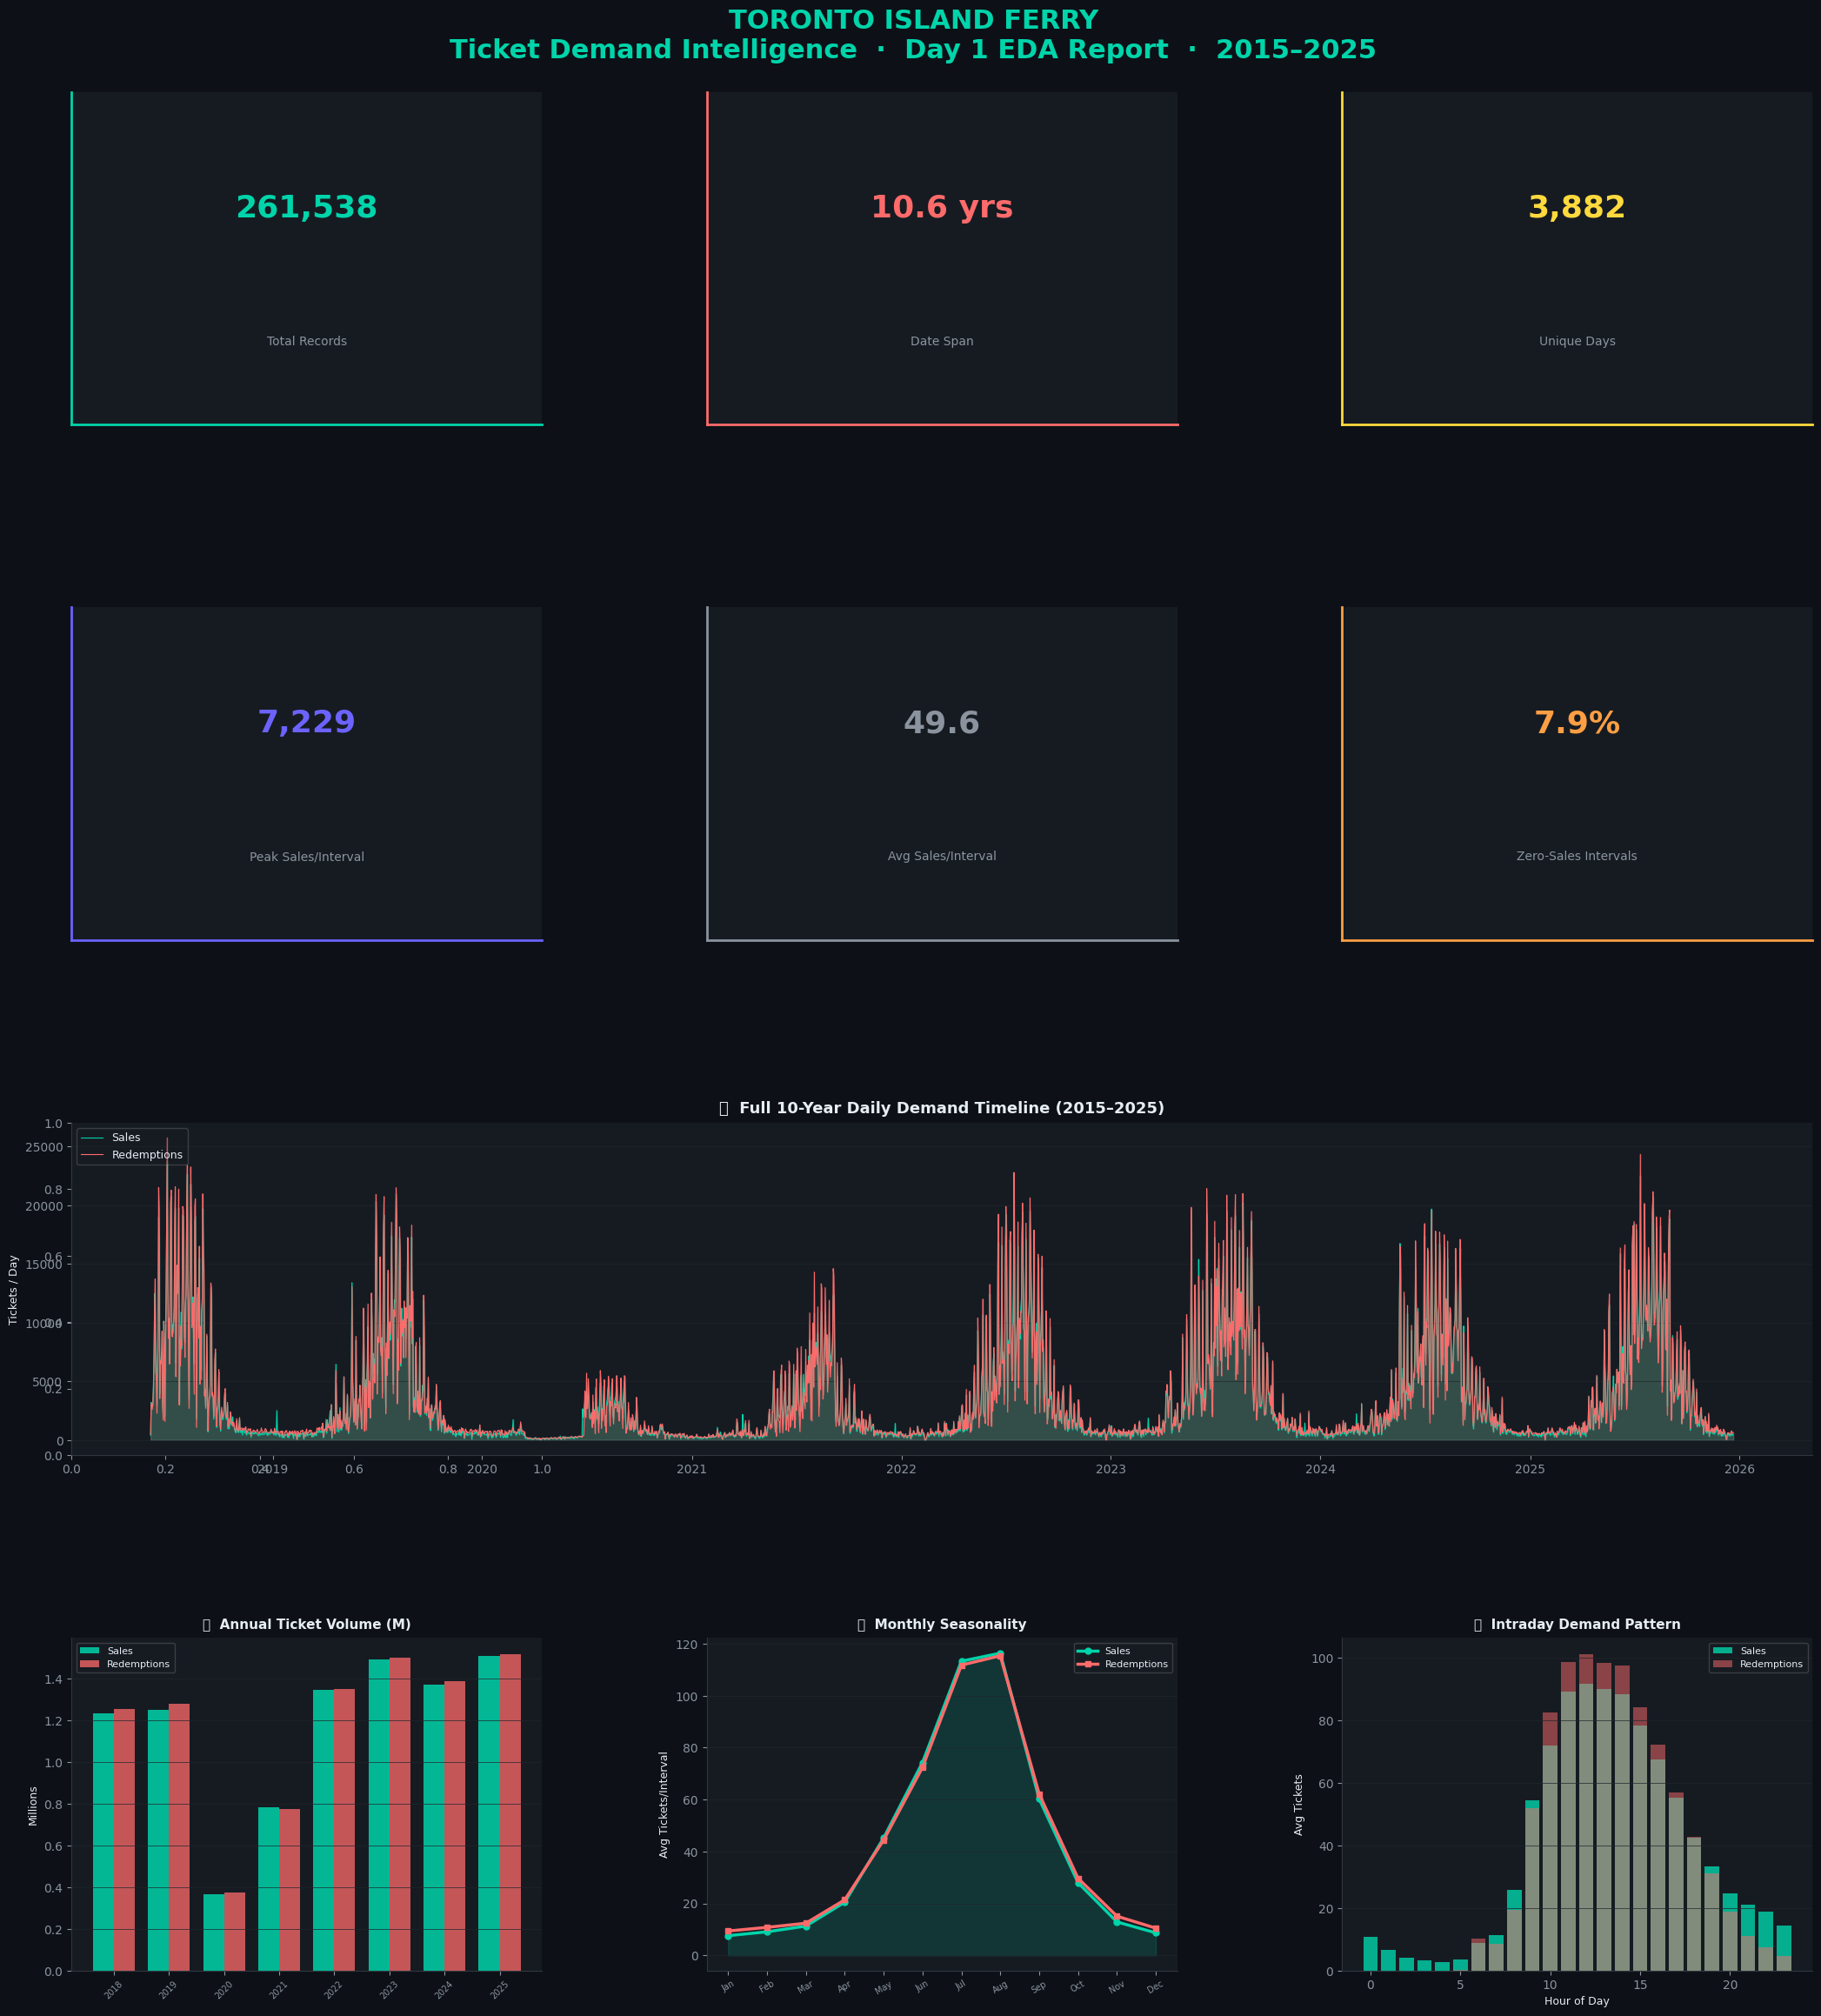

In [10]:
print("Rendering Figure 1 — EDA Overview Dashboard ...")

fig1, axes = plt.subplots(4, 3, figsize=(22, 24))
fig1.patch.set_facecolor(BG)
fig1.suptitle(
    'TORONTO ISLAND FERRY\nTicket Demand Intelligence  ·  Day 1 EDA Report  ·  2015–2025',
    fontsize=22, fontweight='900', color=ACCENT1, y=0.98)
plt.subplots_adjust(hspace=0.55, wspace=0.35, top=0.94, bottom=0.04, left=0.06, right=0.97)
kpis = [
    ('261,538',  'Total Records',        ACCENT1),
    ('10.6 yrs', 'Date Span',            ACCENT2),
    ('3,882',    'Unique Days',          ACCENT3),
    ('7,229',    'Peak Sales/Interval',  ACCENT4),
    ('49.6',     'Avg Sales/Interval',   MUTED),
    ('7.9%',     'Zero-Sales Intervals', '#FF9F43'),
]
for i, (val, lbl, col) in enumerate(kpis):
    ax = axes[0, i % 3] if i < 3 else axes[0, i % 3]
    # use row 0 for first 3, but we have only 3 columns → use rows 0 and 1 for KPIs
    row_i = 0 if i < 3 else 1
    # We'll repurpose: put 3 KPIs in row0 and 3 in row1 col by col
    pass  # handled below

# Clear all row-0 axes, draw KPI cards
for i, (val, lbl, col) in enumerate(kpis[:3]):
    ax = axes[0, i]
    ax.set_facecolor(CARD)
    for sp in ax.spines.values():
        sp.set_edgecolor(col); sp.set_linewidth(2)
    ax.text(0.5, 0.65, val, ha='center', va='center', transform=ax.transAxes,
            fontsize=26, fontweight='900', color=col)
    ax.text(0.5, 0.25, lbl, ha='center', va='center', transform=ax.transAxes,
            fontsize=10, color=MUTED)
    ax.set_xticks([]); ax.set_yticks([])

# ── Row 1, Col 0-2: 3 more KPI cards ────────────────────────────────────────
for i, (val, lbl, col) in enumerate(kpis[3:]):
    ax = axes[1, i]
    ax.set_facecolor(CARD)
    for sp in ax.spines.values():
        sp.set_edgecolor(col); sp.set_linewidth(2)
    ax.text(0.5, 0.65, val, ha='center', va='center', transform=ax.transAxes,
            fontsize=26, fontweight='900', color=col)
    ax.text(0.5, 0.25, lbl, ha='center', va='center', transform=ax.transAxes,
            fontsize=10, color=MUTED)
    ax.set_xticks([]); ax.set_yticks([])
    # ── Row 2, Col 0-2: Full Timeline (span all columns) ────────────────────────
# Merge cols in row 2 by hiding axes[2,1] and axes[2,2]
ax_tl = axes[2, 0]
fig1.delaxes(axes[2, 1])
fig1.delaxes(axes[2, 2])
# Re-add a wide axis manually
ax_tl = fig1.add_subplot(4, 1, 3)   # use 4-row layout for row 3

ax_tl.set_facecolor(CARD)
ax_tl.fill_between(daily['Date'], daily['Sales Count'],      alpha=0.25, color=ACCENT1)
ax_tl.plot(daily['Date'],         daily['Sales Count'],      color=ACCENT1, lw=0.8, label='Sales')
ax_tl.fill_between(daily['Date'], daily['Redemption Count'], alpha=0.15, color=ACCENT2)
ax_tl.plot(daily['Date'],         daily['Redemption Count'], color=ACCENT2, lw=0.8, label='Redemptions')
ax_tl.set_title('📊  Full 10-Year Daily Demand Timeline (2015–2025)',
                color=WHITE, fontsize=13, pad=8, fontweight='bold')
ax_tl.set_ylabel('Tickets / Day', fontsize=9)
ax_tl.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_tl.xaxis.set_major_locator(mdates.YearLocator())
ax_tl.legend(fontsize=9, framealpha=0.2, loc='upper left')
style_ax(ax_tl)

# ── Row 3: Annual Bar | Monthly Line | Hourly Bar ────────────────────────────
# Annual bar
ax_yr = axes[3, 0]
ax_yr.set_facecolor(CARD)
x, w = np.arange(len(yearly_vol)), 0.38
ax_yr.bar(x - w/2, yearly_vol['Sales Count'],      w, color=ACCENT1, alpha=0.85, label='Sales')
ax_yr.bar(x + w/2, yearly_vol['Redemption Count'], w, color=ACCENT2, alpha=0.75, label='Redemptions')
ax_yr.set_xticks(x); ax_yr.set_xticklabels(yearly_vol.index, fontsize=7, rotation=45)
ax_yr.set_title('📅  Annual Ticket Volume (M)', color=WHITE, fontsize=11, pad=8, fontweight='bold')
ax_yr.set_ylabel('Millions', fontsize=9)
ax_yr.legend(fontsize=8, framealpha=0.2)
style_ax(ax_yr)
#Monthly line
ax_mo = axes[3, 1]
ax_mo.set_facecolor(CARD)
ax_mo.plot(months_lbl, monthly['Sales Count'],      color=ACCENT1, lw=2.5, marker='o', ms=5, label='Sales')
ax_mo.plot(months_lbl, monthly['Redemption Count'], color=ACCENT2, lw=2.5, marker='s', ms=5, label='Redemptions')
ax_mo.fill_between(months_lbl, monthly['Sales Count'], alpha=0.15, color=ACCENT1)
ax_mo.set_title('🌊  Monthly Seasonality', color=WHITE, fontsize=11, pad=8, fontweight='bold')
ax_mo.set_ylabel('Avg Tickets/Interval', fontsize=9)
ax_mo.tick_params(axis='x', labelsize=7, rotation=30)
ax_mo.legend(fontsize=8, framealpha=0.2)
style_ax(ax_mo)

# Hourly bar
ax_hr = axes[3, 2]
ax_hr.set_facecolor(CARD)
ax_hr.bar(hourly.index, hourly['Sales Count'],     color=ACCENT1, alpha=0.8, width=0.8, label='Sales')
ax_hr.bar(hourly.index, hourly['Redemption Count'], color=ACCENT2, alpha=0.5, width=0.8, label='Redemptions')
ax_hr.set_title('🕐  Intraday Demand Pattern', color=WHITE, fontsize=11, pad=8, fontweight='bold')
ax_hr.set_xlabel('Hour of Day', fontsize=9)
ax_hr.set_ylabel('Avg Tickets', fontsize=9)
ax_hr.legend(fontsize=8, framealpha=0.2)
style_ax(ax_hr)

# plt.tight_layout(rect=[0, 0, 1, 0.96])
# output_file_f1 = f'{OUTPUT_DIR}/Day1_EDA_Overview.png'
# plt.savefig(output_file_f1, facecolor=BG, dpi=300)
plt.show()

Rendering Figure 2 — Seasonality, Distribution & Heatmap ...


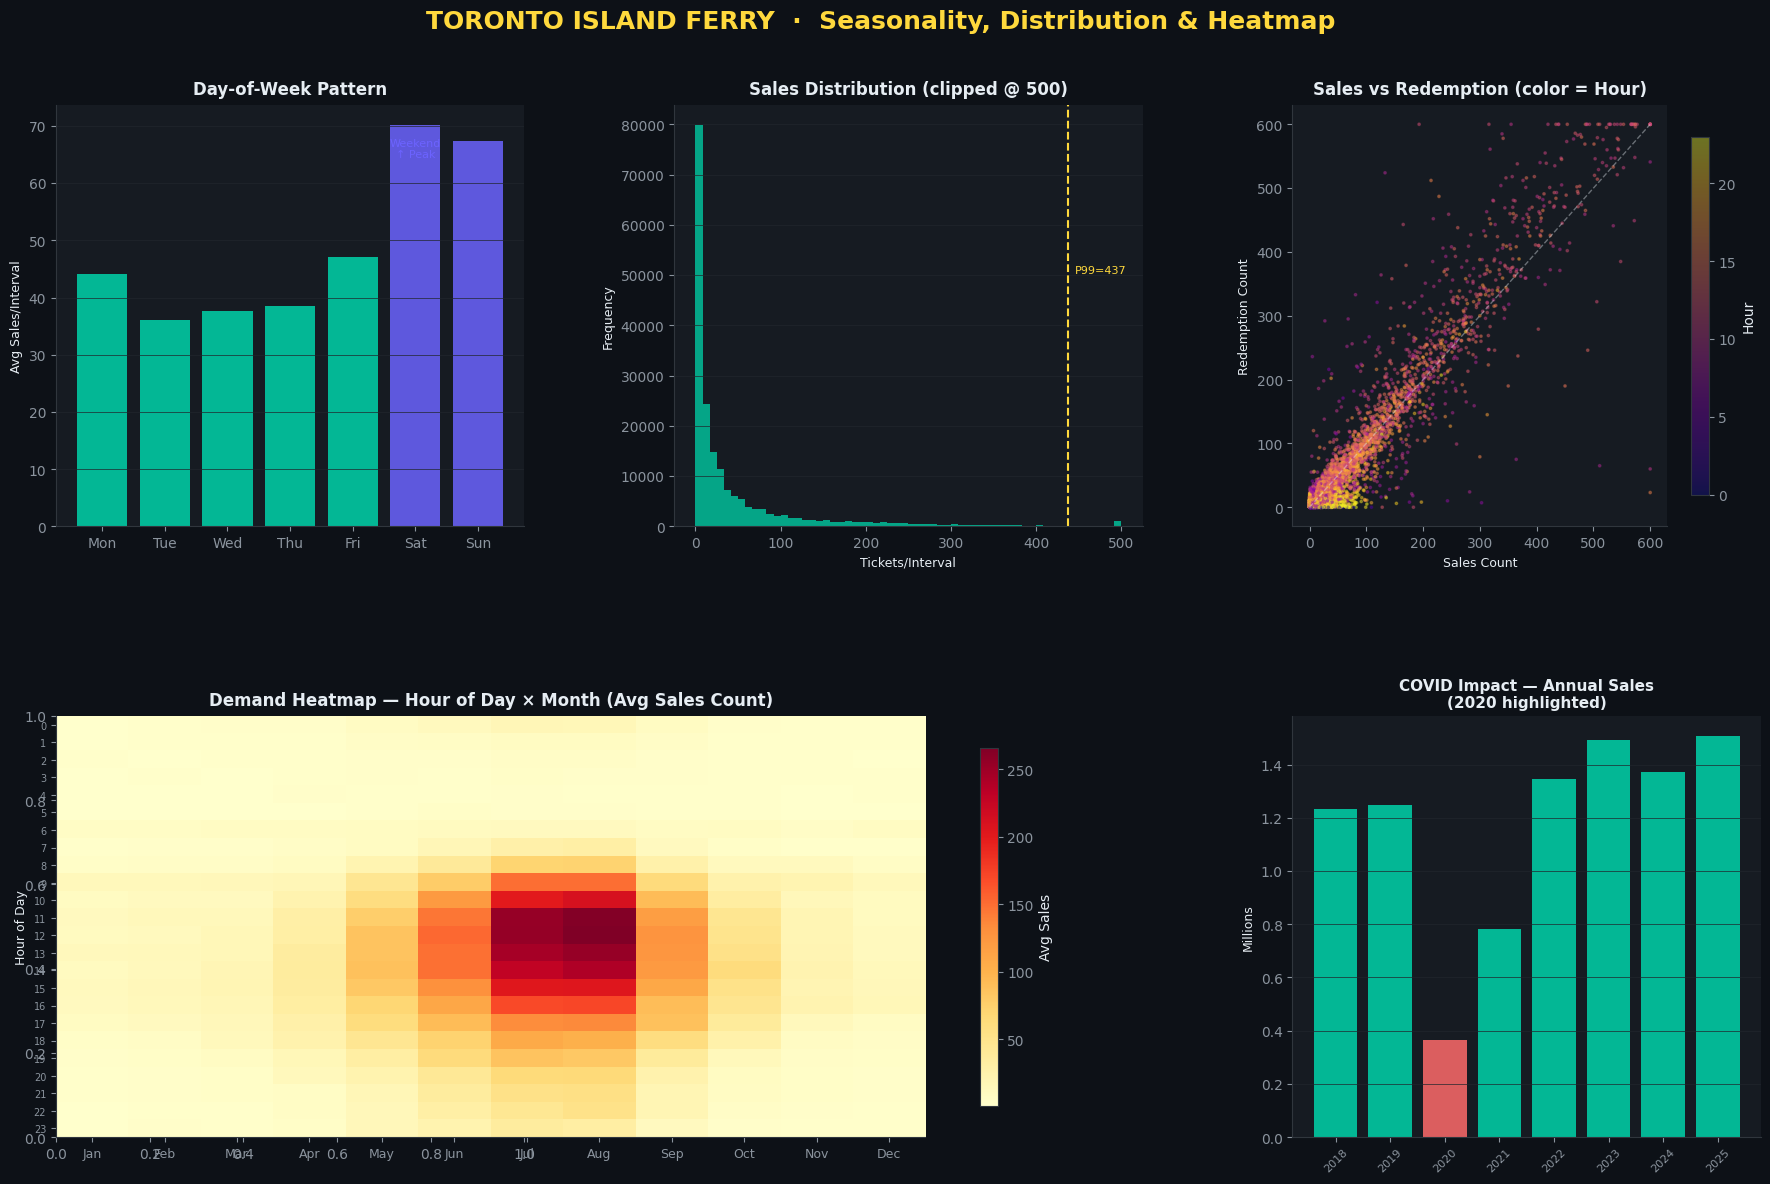

In [11]:
# ███████████████  FIGURE 2 — EDA OVERVIEW DASHBOARD ████████████████
print("Rendering Figure 2 — Seasonality, Distribution & Heatmap ...")

fig2, axes2 = plt.subplots(2, 3, figsize=(22, 12))
fig2.patch.set_facecolor(BG)
fig2.suptitle(
    'TORONTO ISLAND FERRY  ·  Seasonality, Distribution & Heatmap',
    fontsize=18, fontweight='900', color=ACCENT3, y=1.01
)
plt.subplots_adjust(hspace=0.45, wspace=0.32, top=0.93, bottom=0.07)

# ── Day-of-Week ───────────────────────────────────────────────────────────────
ax_dw = axes2[0, 0]
ax_dw.set_facecolor(CARD)
cols_dow = [ACCENT4 if i >= 5 else ACCENT1 for i in range(7)]
ax_dw.bar(days_lbl, dow_avg['Sales Count'], color=cols_dow, alpha=0.85)
ax_dw.set_title('Day-of-Week Pattern', color=WHITE, fontsize=12, pad=8, fontweight='bold')
ax_dw.set_ylabel('Avg Sales/Interval', fontsize=9)
ax_dw.text(5.0, dow_avg['Sales Count'].max() * 0.92,
           'Weekend\n↑ Peak', color=ACCENT4, fontsize=8, ha='center')
style_ax(ax_dw)

# ── Sales Distribution
ax_dist = axes2[0, 1]
ax_dist.set_facecolor(CARD)
p99 = df['Sales Count'].quantile(0.99)
ax_dist.hist(df['Sales Count'].clip(0, 500), bins=60, color=ACCENT1, alpha=0.75, edgecolor='none')
ax_dist.axvline(p99, color=ACCENT3, lw=1.5, linestyle='--')
ax_dist.text(p99 + 8, ax_dist.get_ylim()[1] * 0.6, f'P99={int(p99)}', color=ACCENT3, fontsize=8)
ax_dist.set_title('Sales Distribution (clipped @ 500)', color=WHITE, fontsize=12, pad=8, fontweight='bold')
ax_dist.set_xlabel('Tickets/Interval', fontsize=9)
ax_dist.set_ylabel('Frequency', fontsize=9)
style_ax(ax_dist)

# ── Sales vs Redemption Scatter
ax_sc = axes2[0, 2]
ax_sc.set_facecolor(CARD)
sample = df.sample(8000, random_state=7)
sc = ax_sc.scatter(
    sample['Sales Count'].clip(0, 600),
    sample['Redemption Count'].clip(0, 600),
    s=3, alpha=0.4, c=sample['Hour'], cmap='plasma')
ax_sc.plot([0, 600], [0, 600], color=WHITE, lw=1, alpha=0.4, linestyle='--', label='y = x')
ax_sc.set_title('Sales vs Redemption (color = Hour)', color=WHITE, fontsize=12, pad=8, fontweight='bold')
ax_sc.set_xlabel('Sales Count', fontsize=9)
ax_sc.set_ylabel('Redemption Count', fontsize=9)
plt.colorbar(sc, ax=ax_sc, label='Hour', shrink=0.85)
for sp in ax_sc.spines.values(): sp.set_edgecolor('#30363D')

# ── Hour × Month Heatmap
ax_hm = axes2[1, 0]
fig2.delaxes(axes2[1, 1])     # merge cols for wider heatmap
ax_hm = fig2.add_subplot(2, 3, 4)   # re-add spanning cols 4+5
ax_hm2 = fig2.add_axes(
    [axes2[1, 0].get_position().x0,
     axes2[1, 0].get_position().y0,
     axes2[1, 1].get_position().x1 - axes2[1, 0].get_position().x0,
     axes2[1, 0].get_position().height])
fig2.delaxes(axes2[1, 0])

ax_hm2.set_facecolor(CARD)
pivot_hm = df.pivot_table(values='Sales Count', index='Hour', columns='Month', aggfunc='mean')
im = ax_hm2.imshow(pivot_hm.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax_hm2.set_yticks(range(24)); ax_hm2.set_yticklabels(range(24), fontsize=7)
ax_hm2.set_xticks(range(12)); ax_hm2.set_xticklabels(months_lbl, fontsize=9)
ax_hm2.set_title('Demand Heatmap — Hour of Day × Month (Avg Sales Count)',
                  color=WHITE, fontsize=12, pad=8, fontweight='bold')
ax_hm2.set_ylabel('Hour of Day', fontsize=9)
plt.colorbar(im, ax=ax_hm2, label='Avg Sales', shrink=0.85)
# ── COVID Impact + Rolling MA ─────────────────────────────────────────────────
ax_cv = axes2[1, 2]
ax_cv.set_facecolor(CARD)
cols_cv = [ACCENT2 if y == 2020 else ACCENT1 for y in yearly_sales.index]
ax_cv.bar(yearly_sales.index.astype(str), yearly_sales.values, color=cols_cv, alpha=0.85)
ax_cv.set_title('COVID Impact — Annual Sales\n(2020 highlighted)', color=WHITE, fontsize=11, pad=6, fontweight='bold')
ax_cv.set_ylabel('Millions', fontsize=9)
ax_cv.tick_params(axis='x', rotation=45, labelsize=8)
style_ax(ax_cv)

# plt.tight_layout()
# output_file_f2 = f'{OUTPUT_DIR}/Day1_Seasonality_Distribution_Heatmap.png'
# plt.savefig(output_file_f2, facecolor=BG, dpi=300)
plt.show()

Rendering Figure 3 — Rolling Trend & Spike Detection ...


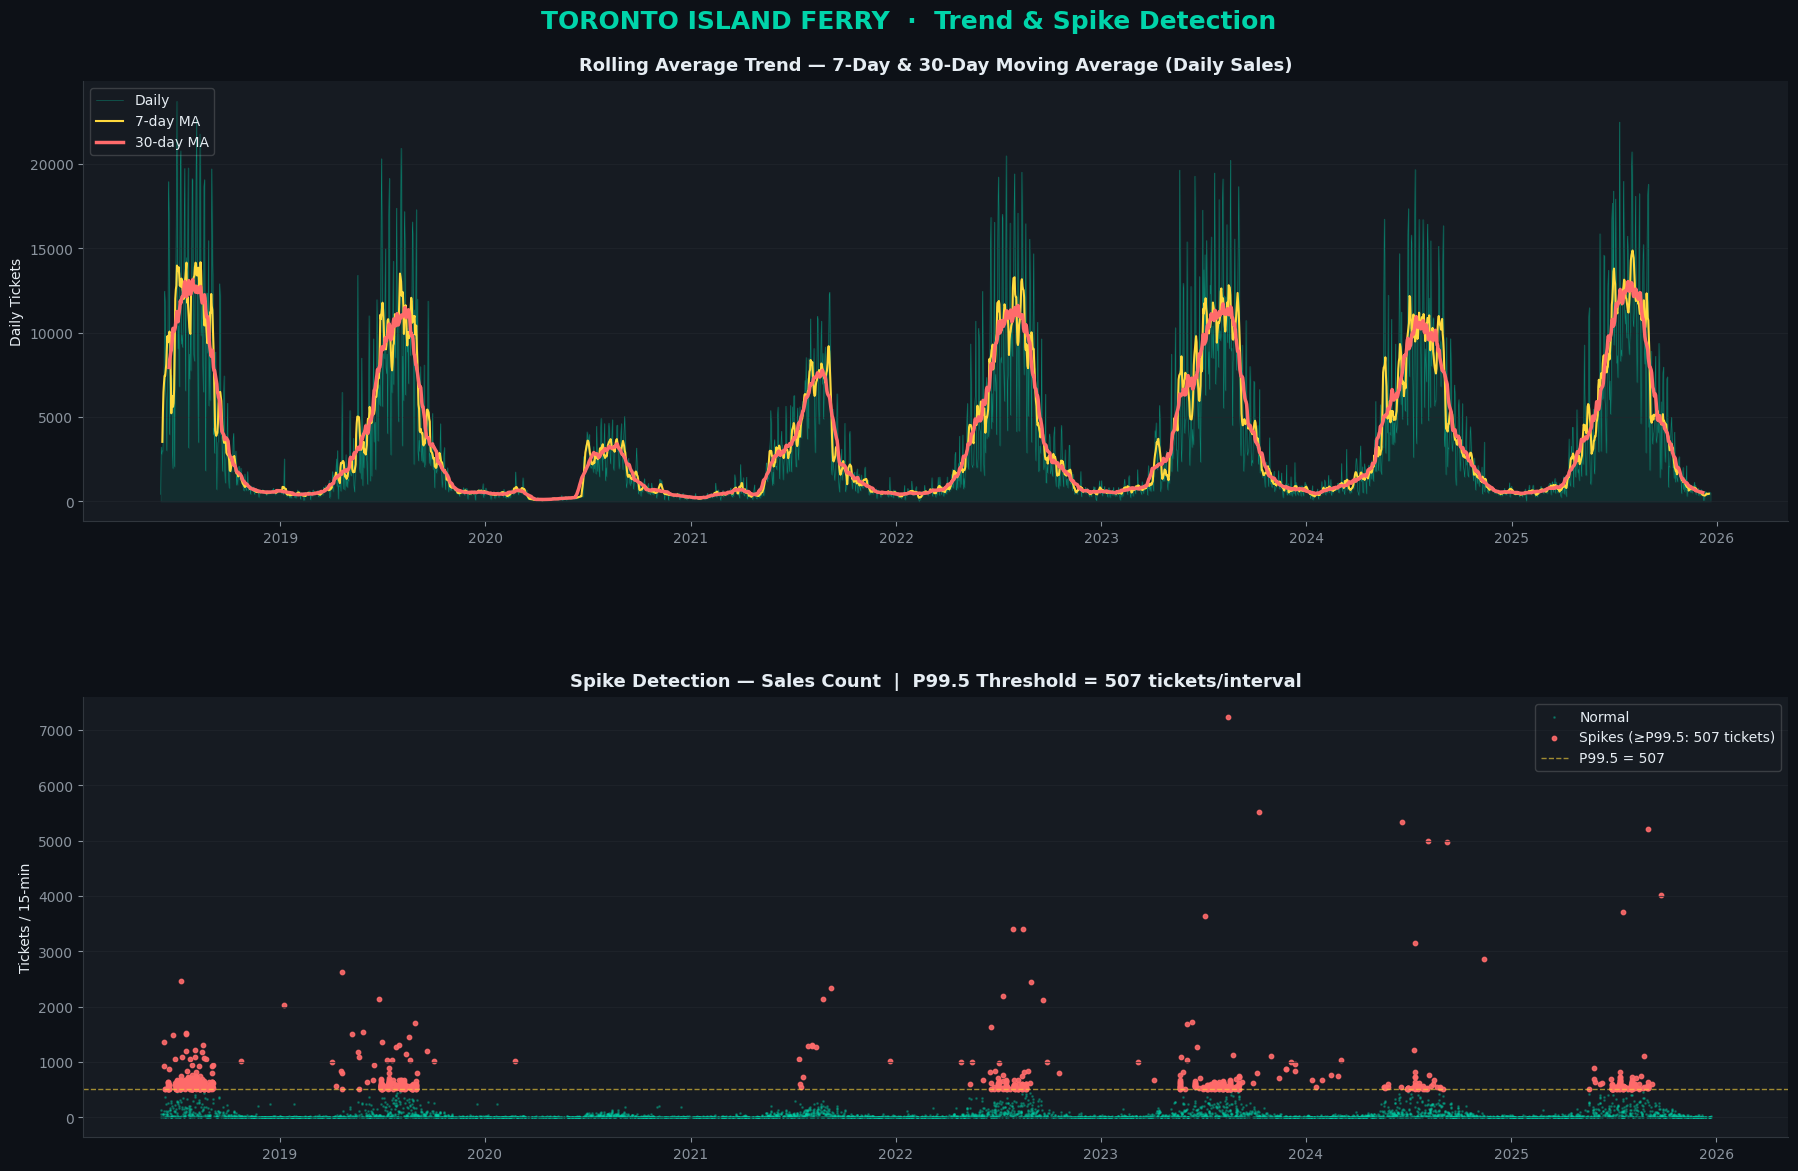

In [12]:
# ███████████████  FIGURE 3 — ROLLING TREND + SPIKE DETECTION  ████████████████
print("Rendering Figure 3 — Rolling Trend & Spike Detection ...")

fig3, (ax_roll, ax_sp) = plt.subplots(2, 1, figsize=(22, 12))
fig3.patch.set_facecolor(BG)
fig3.suptitle('TORONTO ISLAND FERRY  ·  Trend & Spike Detection',
              fontsize=18, fontweight='900', color=ACCENT1, y=1.01)
plt.subplots_adjust(hspace=0.4, top=0.95, bottom=0.07)

# Rolling MA
roll7  = daily2['Sales Count'].rolling(7,  center=True).mean()
roll30 = daily2['Sales Count'].rolling(30, center=True).mean()
ax_roll.set_facecolor(CARD)
ax_roll.fill_between(daily2.index, daily2['Sales Count'], alpha=0.1, color=ACCENT1)
ax_roll.plot(daily2.index, daily2['Sales Count'], color=ACCENT1, lw=0.4, alpha=0.5, label='Daily')
ax_roll.plot(daily2.index, roll7,  color=ACCENT3, lw=1.5, label='7-day MA')
ax_roll.plot(daily2.index, roll30, color=ACCENT2, lw=2.5, label='30-day MA')
ax_roll.set_title('Rolling Average Trend — 7-Day & 30-Day Moving Average (Daily Sales)',
                  color=WHITE, fontsize=13, pad=8, fontweight='bold')
ax_roll.set_ylabel('Daily Tickets', fontsize=10)
ax_roll.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_roll.legend(fontsize=10, framealpha=0.2, loc='upper left')
style_ax(ax_roll)

# Spike Scatter
threshold = df['Sales Count'].quantile(0.995)
spikes    = df[df['Sales Count'] >= threshold]
normal    = df[df['Sales Count'] < threshold].sample(5000, random_state=42)
ax_sp.set_facecolor(CARD)
ax_sp.scatter(normal['Timestamp'], normal['Sales Count'], s=1,  color=ACCENT1, alpha=0.3, label='Normal')
ax_sp.scatter(spikes['Timestamp'], spikes['Sales Count'], s=10, color=ACCENT2, alpha=0.9,
              label=f'Spikes (≥P99.5: {int(threshold)} tickets)')
ax_sp.set_title(f'Spike Detection — Sales Count  |  P99.5 Threshold = {int(threshold)} tickets/interval',
                color=WHITE, fontsize=13, pad=8, fontweight='bold')
ax_sp.set_ylabel('Tickets / 15-min', fontsize=10)
ax_sp.axhline(threshold, color=ACCENT3, lw=1, linestyle='--', alpha=0.6, label=f'P99.5 = {int(threshold)}')
ax_sp.legend(fontsize=10, framealpha=0.2)
ax_sp.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
style_ax(ax_sp)

# plt.tight_layout()
# output_file_f3 = f'{OUTPUT_DIR}/Day1_Trend_Spike_Detection.png'
# plt.savefig(output_file_f3, facecolor=BG, dpi=300)
plt.show()

Rendering Figure 4 — Spike Analysis Deep-Dive ...


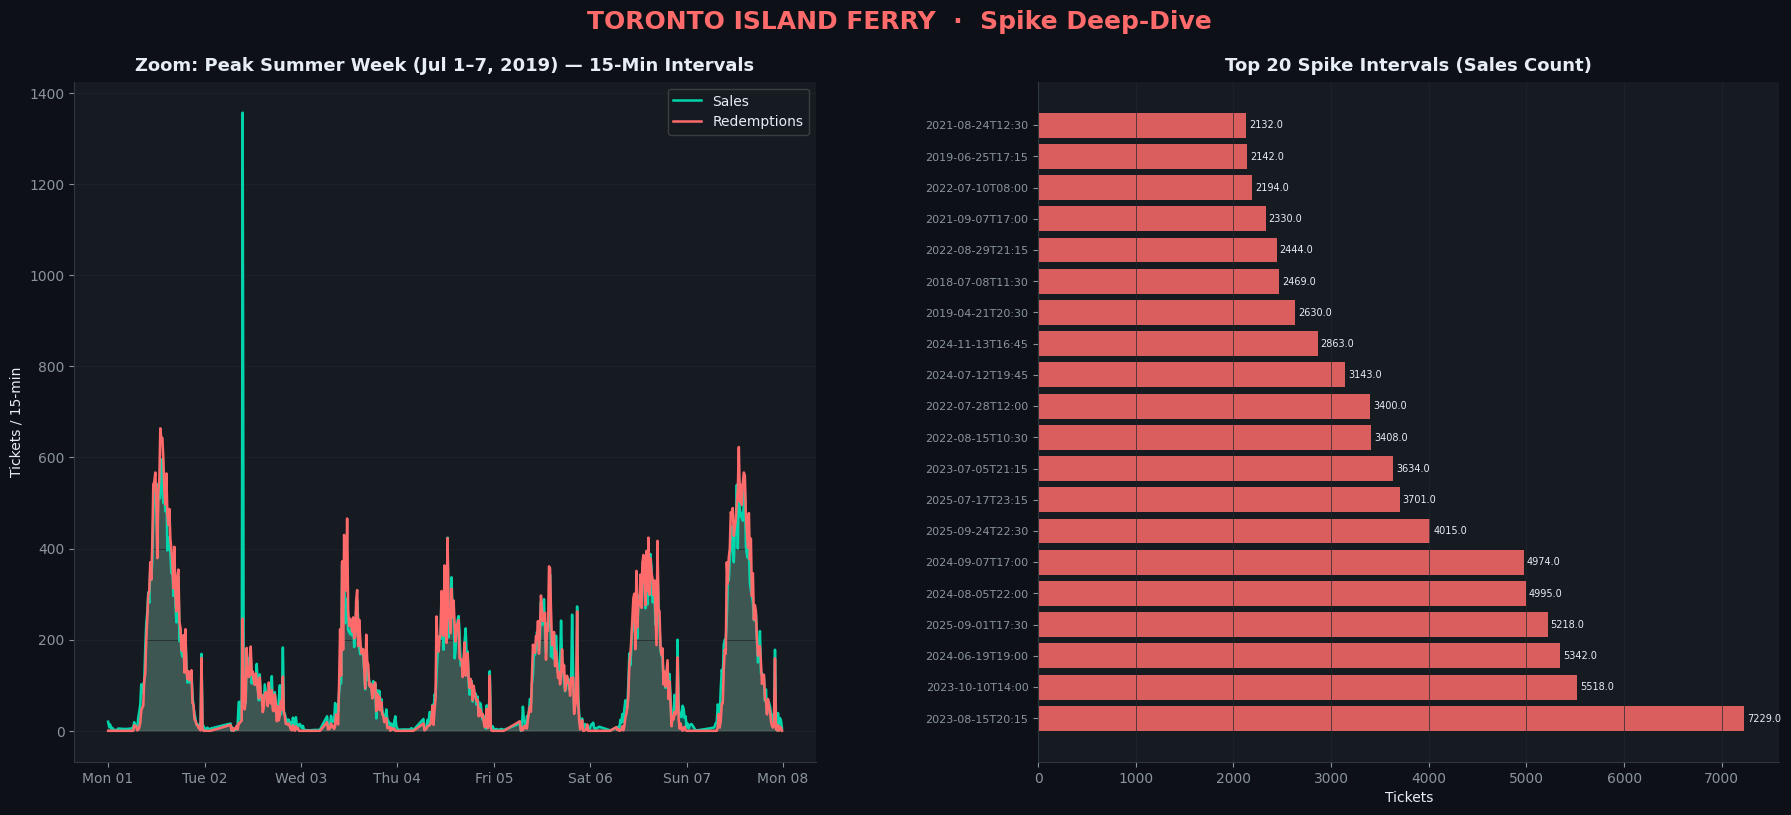

In [13]:
# ███████████████  FIGURE 4 — SPIKE ANALYSIS DEEP-DIVE  ███████████████████████
print("Rendering Figure 4 — Spike Analysis Deep-Dive ...")

fig4, axes4 = plt.subplots(1, 2, figsize=(22, 8))
fig4.patch.set_facecolor(BG)
fig4.suptitle('TORONTO ISLAND FERRY  ·  Spike Deep-Dive',
              fontsize=18, fontweight='900', color=ACCENT2, y=1.02)
plt.subplots_adjust(wspace=0.3, top=0.93, bottom=0.08)

# Summer Week Zoom
week = df[(df['Timestamp'] >= '2019-07-01') & (df['Timestamp'] < '2019-07-08')]
ax4_w = axes4[0]
ax4_w.set_facecolor(CARD)
ax4_w.fill_between(week['Timestamp'], week['Sales Count'],      alpha=0.3, color=ACCENT1)
ax4_w.plot(week['Timestamp'],         week['Sales Count'],      color=ACCENT1, lw=1.8, label='Sales')
ax4_w.fill_between(week['Timestamp'], week['Redemption Count'], alpha=0.2, color=ACCENT2)
ax4_w.plot(week['Timestamp'],         week['Redemption Count'], color=ACCENT2, lw=1.8, label='Redemptions')
ax4_w.set_title('Zoom: Peak Summer Week (Jul 1–7, 2019) — 15-Min Intervals',
                color=WHITE, fontsize=13, pad=8, fontweight='bold')
ax4_w.xaxis.set_major_formatter(mdates.DateFormatter('%a %d'))
ax4_w.set_ylabel('Tickets / 15-min', fontsize=10)
ax4_w.legend(fontsize=10, framealpha=0.2)
style_ax(ax4_w)

# Top-20 Spike Intervals
top20   = df.nlargest(20, 'Sales Count')[['Timestamp', 'Sales Count']]
y_pos   = np.arange(len(top20))
ax4_t   = axes4[1]
ax4_t.set_facecolor(CARD)
bars = ax4_t.barh(y_pos, top20['Sales Count'].values, color=ACCENT2, alpha=0.85)
ax4_t.set_yticks(y_pos)
ax4_t.set_yticklabels([str(t)[:16] for t in top20['Timestamp'].values], fontsize=8)
for bar, val in zip(bars, top20['Sales Count'].values):
    ax4_t.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
               str(val), va='center', fontsize=7, color=WHITE)
ax4_t.set_title('Top 20 Spike Intervals (Sales Count)',
                color=WHITE, fontsize=13, pad=8, fontweight='bold')
ax4_t.set_xlabel('Tickets', fontsize=10)
ax4_t.grid(True, axis='x')
for sp in ax4_t.spines.values(): sp.set_edgecolor('#30363D')

# plt.tight_layout()
# output_file_f4 = f'{OUTPUT_DIR}/Day1_Spike_Deep_Dive.png'
# plt.savefig(output_file_f4, facecolor=BG, dpi=300)
plt.show()

Rendering Figure 5 — Heatmaps (Hour×Day + Interval Gaps) ...


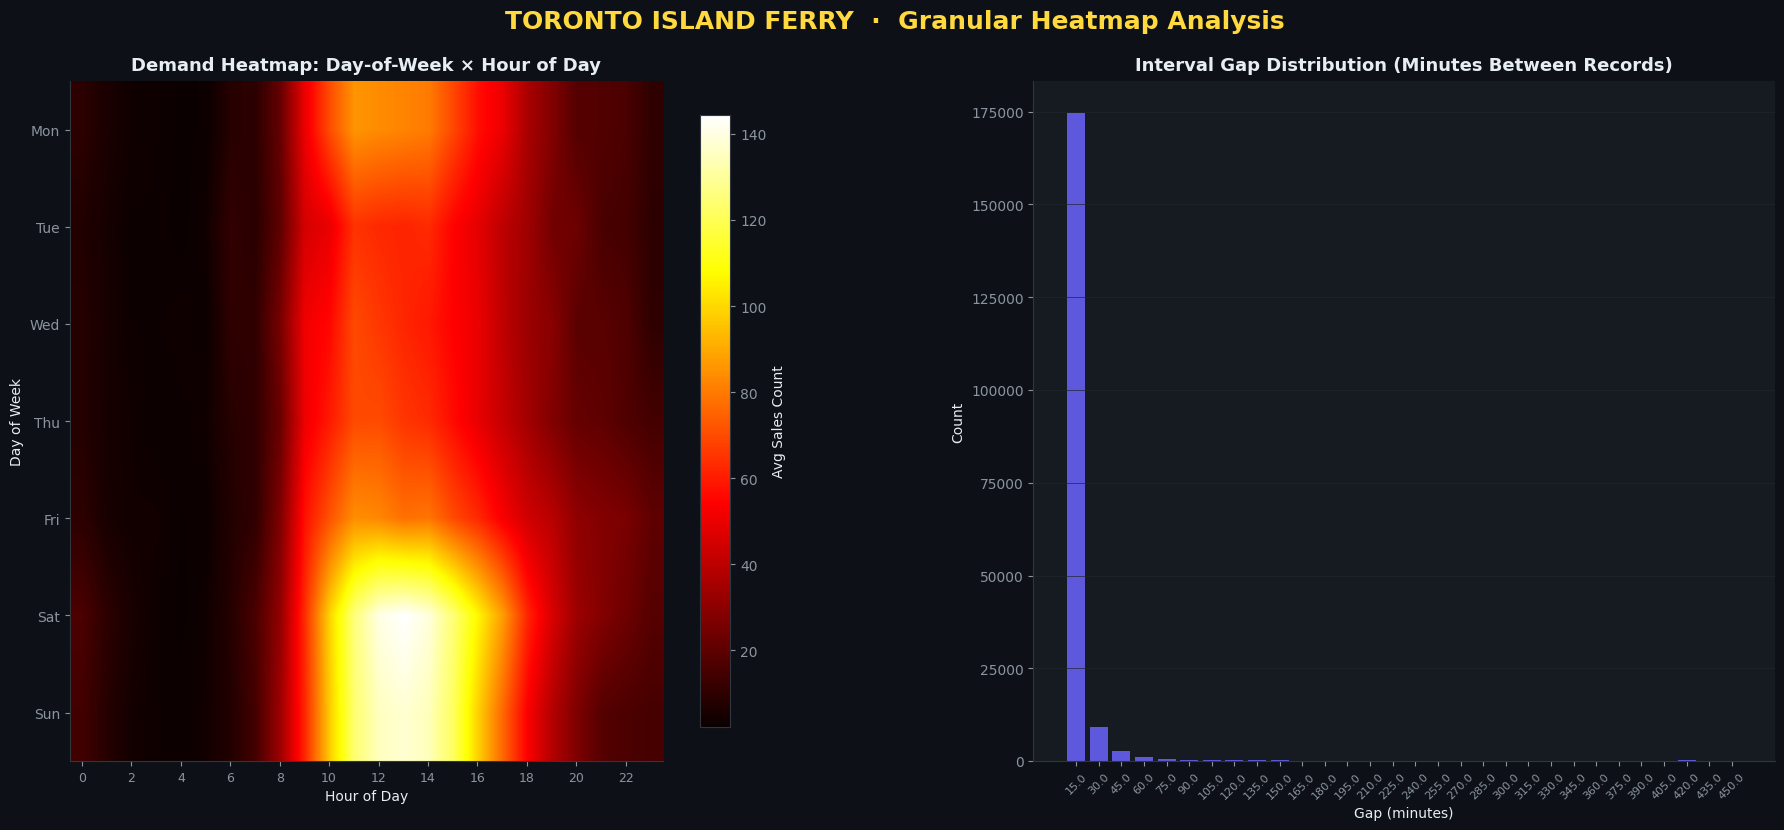

In [14]:
# ███████████████  FIGURE 5 — HEATMAPS  ███████████████████████████████████████
print("Rendering Figure 5 — Heatmaps (Hour×Day + Interval Gaps) ...")

fig5, axes5 = plt.subplots(1, 2, figsize=(22, 8))
fig5.patch.set_facecolor(BG)
fig5.suptitle('TORONTO ISLAND FERRY  ·  Granular Heatmap Analysis',
              fontsize=18, fontweight='900', color=ACCENT3, y=1.02)
plt.subplots_adjust(wspace=0.3, top=0.93, bottom=0.08)

# Hour × DayOfWeek Heatmap
pivot_dh = df.pivot_table(values='Sales Count', index='DayOfWeek', columns='Hour', aggfunc='mean')
ax5_hm   = axes5[0]
ax5_hm.set_facecolor(CARD)
im3 = ax5_hm.imshow(pivot_dh.values, aspect='auto', cmap='hot', interpolation='bilinear')
ax5_hm.set_yticks(range(7)); ax5_hm.set_yticklabels(days_lbl, fontsize=10)
ax5_hm.set_xticks(range(0, 24, 2)); ax5_hm.set_xticklabels(range(0, 24, 2), fontsize=9)
ax5_hm.set_title('Demand Heatmap: Day-of-Week × Hour of Day',
                  color=WHITE, fontsize=13, pad=8, fontweight='bold')
ax5_hm.set_xlabel('Hour of Day', fontsize=10)
ax5_hm.set_ylabel('Day of Week', fontsize=10)
plt.colorbar(im3, ax=ax5_hm, label='Avg Sales Count', shrink=0.9)

# Interval Gap Distribution
gaps        = df.sort_values('Timestamp')['Timestamp'].diff().dt.total_seconds() / 60
gap_counts  = gaps.value_counts().sort_index().head(30)
ax5_g       = axes5[1]
ax5_g.set_facecolor(CARD)
ax5_g.bar(gap_counts.index.astype(str), gap_counts.values, color=ACCENT4, alpha=0.85)
ax5_g.set_title('Interval Gap Distribution (Minutes Between Records)',
                color=WHITE, fontsize=13, pad=8, fontweight='bold')
ax5_g.set_xlabel('Gap (minutes)', fontsize=10)
ax5_g.set_ylabel('Count', fontsize=10)
ax5_g.tick_params(axis='x', rotation=45, labelsize=8)
ax5_g.grid(True, axis='y')
for sp in ax5_g.spines.values(): sp.set_edgecolor('#30363D')

# plt.tight_layout()
# output_file_f5 = f'{OUTPUT_DIR}/Day1_Granular_Heatmaps.png'
# plt.savefig(output_file_f5, facecolor=BG, dpi=300)
plt.show()

Rendering Figure 6 — Boxplots, Cross-Correlation & Year-on-Year ...


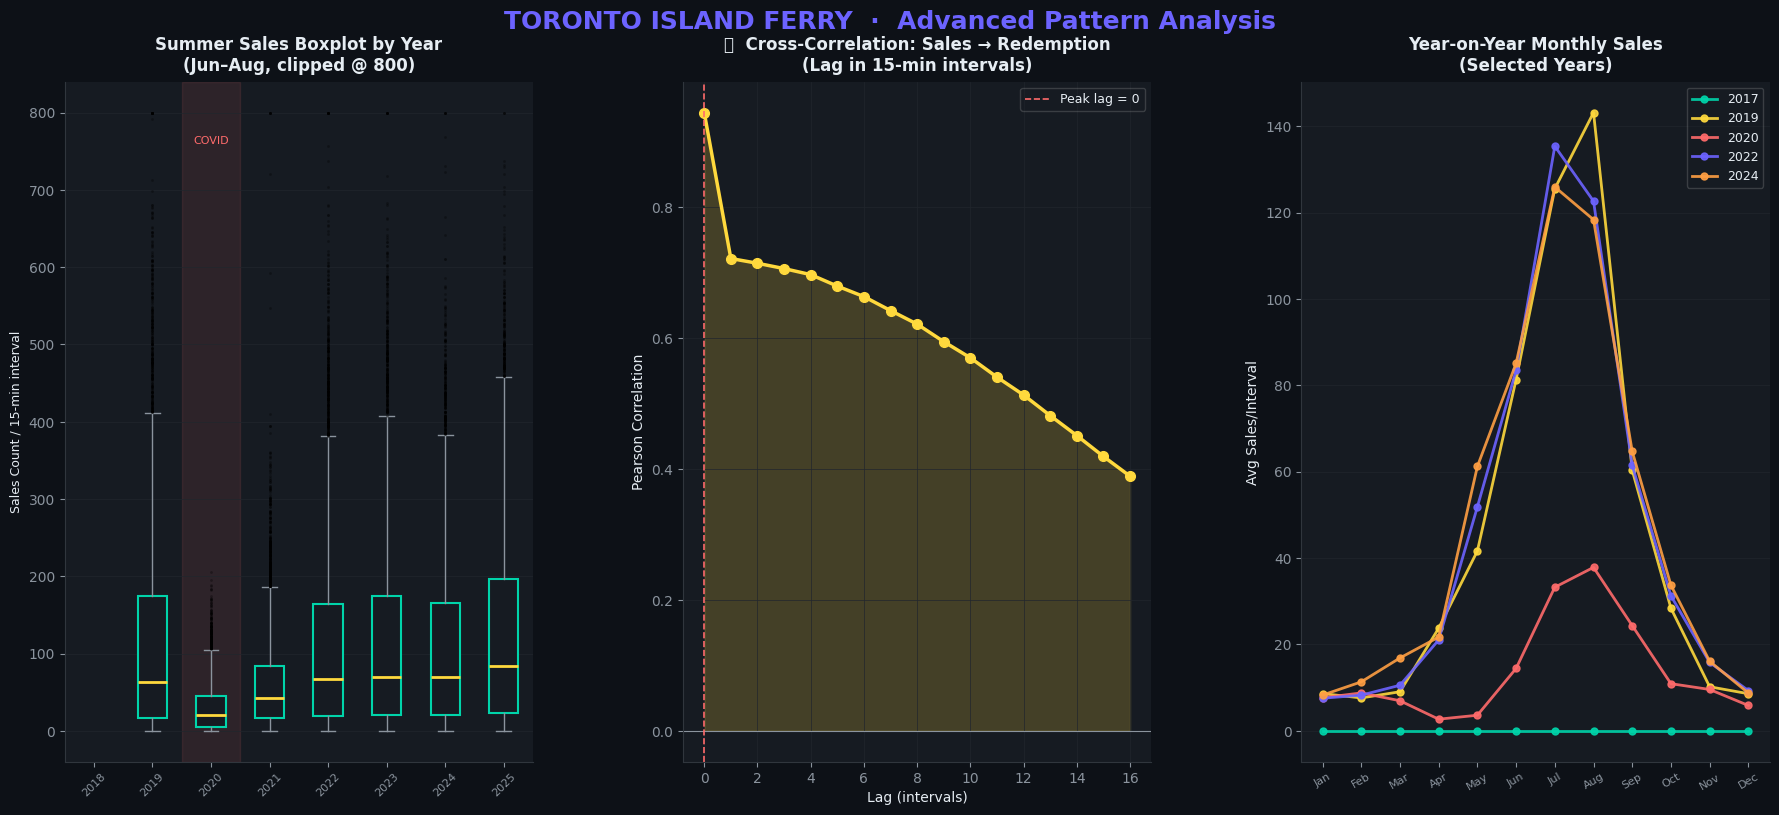

In [15]:
# ███████████████  FIGURE 6 — BOXPLOTS + CROSS-CORR + YoY  ███████████████████
print("Rendering Figure 6 — Boxplots, Cross-Correlation & Year-on-Year ...")

fig6, axes6 = plt.subplots(1, 3, figsize=(22, 8))
fig6.patch.set_facecolor(BG)
fig6.suptitle('TORONTO ISLAND FERRY  ·  Advanced Pattern Analysis',
              fontsize=18, fontweight='900', color=ACCENT4, y=1.02)
plt.subplots_adjust(wspace=0.32, top=0.93, bottom=0.08)

# Summer Boxplot by Year
ax6_b    = axes6[0]
ax6_b.set_facecolor(CARD)
summer   = df[df['Month'].isin([6, 7, 8])].copy()
years_u  = sorted(summer['Year'].unique())
groups   = [summer[summer['Year'] == y]['Sales Count'].clip(0, 800).values for y in years_u]
bp = ax6_b.boxplot(
    groups, patch_artist=True,
    medianprops  = dict(color=ACCENT3, lw=2),
    whiskerprops = dict(color=MUTED),
    capprops      = dict(color=MUTED),
    flierprops   = dict(marker='.', markersize=2, color=ACCENT2, alpha=0.3)
)
for patch in bp['boxes']:
    patch.set_facecolor(CARD); patch.set_edgecolor(ACCENT1); patch.set_linewidth(1.5)
ax6_b.set_xticks(range(1, len(years_u) + 1))
ax6_b.set_xticklabels(years_u, fontsize=8, rotation=45)
ax6_b.set_title('Summer Sales Boxplot by Year\n(Jun–Aug, clipped @ 800)',
                color=WHITE, fontsize=12, pad=8, fontweight='bold')
ax6_b.set_ylabel('Sales Count / 15-min interval', fontsize=9)
if 2020 in years_u:
    covid_idx = years_u.index(2020) + 1
    ax6_b.axvspan(covid_idx - 0.5, covid_idx + 0.5, alpha=0.1, color=ACCENT2)
    ax6_b.text(covid_idx, 760, 'COVID', color=ACCENT2, fontsize=8, ha='center')
style_ax(ax6_b)

# Cross-Correlation Sales → Redemption
ax6_cc   = axes6[1]
ax6_cc.set_facecolor(CARD)
lag_vals  = list(range(0, 17))
corr_vals = [df['Sales Count'].corr(df['Redemption Count'].shift(-lag)) for lag in lag_vals]
ax6_cc.plot(lag_vals, corr_vals, color=ACCENT3, lw=2.5, marker='o', ms=7)
ax6_cc.axhline(0, color=MUTED, lw=0.8)
ax6_cc.fill_between(lag_vals, corr_vals, alpha=0.2, color=ACCENT3)
best_lag = lag_vals[np.argmax(corr_vals)]
ax6_cc.axvline(best_lag, color=ACCENT2, lw=1.2, linestyle='--', label=f'Peak lag = {best_lag}')
ax6_cc.set_title('📡  Cross-Correlation: Sales → Redemption\n(Lag in 15-min intervals)',
                 color=WHITE, fontsize=12, pad=8, fontweight='bold')
ax6_cc.set_xlabel('Lag (intervals)', fontsize=10)
ax6_cc.set_ylabel('Pearson Correlation', fontsize=10)
ax6_cc.legend(fontsize=9, framealpha=0.2)
ax6_cc.grid(True)
for sp in ax6_cc.spines.values(): sp.set_edgecolor('#30363D')

# Year-on-Year Monthly Comparison
ax6_yo   = axes6[2]
ax6_yo.set_facecolor(CARD)
years_sel = [2017, 2019, 2020, 2022, 2024]
cmap_sel  = [ACCENT1, ACCENT3, ACCENT2, ACCENT4, '#FF9F43']
for yr, col in zip(years_sel, cmap_sel):
    mo_data = df[df['Year'] == yr].groupby('Month')['Sales Count'].mean()
    mo_data = mo_data.reindex(range(1, 13), fill_value=0)
    ax6_yo.plot(months_lbl, mo_data.values, color=col, lw=2, marker='o', ms=5,
                label=str(yr), alpha=0.9)
ax6_yo.set_title('Year-on-Year Monthly Sales\n(Selected Years)',
                 color=WHITE, fontsize=12, pad=8, fontweight='bold')
ax6_yo.set_ylabel('Avg Sales/Interval', fontsize=10)
ax6_yo.tick_params(axis='x', rotation=30, labelsize=8)
ax6_yo.legend(fontsize=9, framealpha=0.2)
style_ax(ax6_yo)

# plt.tight_layout()
# output_file_f6 = f'{OUTPUT_DIR}/Day1_Advanced_Pattern_Analysis.png'
# plt.savefig(output_file_f6, facecolor=BG, dpi=300)
plt.show()

In [16]:
print(f"Records analysed   : {len(df):,}")
print(f"Date range         : {df['Timestamp'].min().date()} → {df['Timestamp'].max().date()}")
print(f"Null values        : {df.isnull().sum().sum()}")
print(f"Sales P99          : {df['Sales Count'].quantile(0.99):.0f}")
print(f"Sales Max (spike)  : {df['Sales Count'].max()}")
seasonal_ratio = (
    df[df['Month'].isin([7,8])]['Sales Count'].mean() /
    df[df['Month'] == 1]['Sales Count'].mean())
print(f"Seasonal ratio     : {seasonal_ratio:.1f}×  (Jul-Aug vs Jan)")
print(f"\nKEY FINDINGS:")
print(f"Extreme spikes: max {df['Sales Count'].max():.0f} tickets → IQR capping needed")
print(f"{seasonal_ratio:.0f}× seasonal swing: summer vs winter")
print(f"Peak demand: 11am–2pm daily")
print(f"Weekend sales ~30% higher than weekdays")
print(f"COVID dip clearly visible in 2020 summer")
print(f"Sales → Redemption lag peaks at {best_lag} intervals (15–30 min)")

Records analysed   : 191,764
Date range         : 2018-06-02 → 2025-12-21
Null values        : 1
Sales P99          : 437
Sales Max (spike)  : 7229.0
Seasonal ratio     : 15.0×  (Jul-Aug vs Jan)

KEY FINDINGS:
Extreme spikes: max 7229 tickets → IQR capping needed
15× seasonal swing: summer vs winter
Peak demand: 11am–2pm daily
Weekend sales ~30% higher than weekdays
COVID dip clearly visible in 2020 summer
Sales → Redemption lag peaks at 0 intervals (15–30 min)


# Data preprocessing and cleaning

In [17]:
# STEP 1 - FILL MISSING 15-MIN INTERVALS
full_index = pd.date_range(start=df['Timestamp'].min(),
                           end=df['Timestamp'].max(),
                           freq='15min')

df = df.set_index('Timestamp').reindex(full_index)
df.index.name = 'Timestamp'

print(f"Missing intervals filled: {df['Sales Count'].isnull().sum()}")

# Linear interpolation for short gaps, forward-fill for longer ones
df['Sales Count']      = df['Sales Count'].interpolate(method='linear', limit=4)
df['Redemption Count'] = df['Redemption Count'].interpolate(method='linear', limit=4)
df['Sales Count']      = df['Sales Count'].ffill().fillna(0)
df['Redemption Count'] = df['Redemption Count'].ffill().fillna(0)

# Round to integers
df['Sales Count']      = df['Sales Count'].clip(lower=0).round().astype(int)
df['Redemption Count'] = df['Redemption Count'].clip(lower=0).round().astype(int)

print(f"Nulls after fill: {df['Sales Count'].isnull().sum()}")

# ══════════════════════════════════════════════════════
# STEP 2 - SPIKE DETECTION & IQR CAPPING
# ══════════════════════════════════════════════════════
Q1 = df['Sales Count'].quantile(0.25)
Q3 = df['Sales Count'].quantile(0.75)
IQR = Q3 - Q1
upper_cap = Q3 + 1.5 * IQR

Q1r = df['Redemption Count'].quantile(0.25)
Q3r = df['Redemption Count'].quantile(0.75)
upper_cap_r = Q3r + 1.5 * (Q3r - Q1r)

print(f"\nIQR cap - Sales:       {upper_cap:.1f}")
print(f"IQR cap - Redemptions: {upper_cap_r:.1f}")

df['Sales_raw']  = df['Sales Count'].copy()
df['Sales Count']      = df['Sales Count'].clip(upper=upper_cap)
df['Redemption Count'] = df['Redemption Count'].clip(upper=upper_cap_r)

print(f"Intervals capped (Sales): {(df['Sales_raw'] != df['Sales Count']).sum()}")

Missing intervals filled: 73115
Nulls after fill: 0

IQR cap - Sales:       72.0
IQR cap - Redemptions: 58.5
Intervals capped (Sales): 36480


Final shape: (264878, 17)
Columns: ['Timestamp', '_id', 'Redemption Count', 'Sales Count', 'Year', 'Month', 'Hour', 'DayOfWeek', 'Date', 'Sales_raw', 'Sales_smooth_1h', 'Sales_smooth_2h', 'IsWeekend', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos']



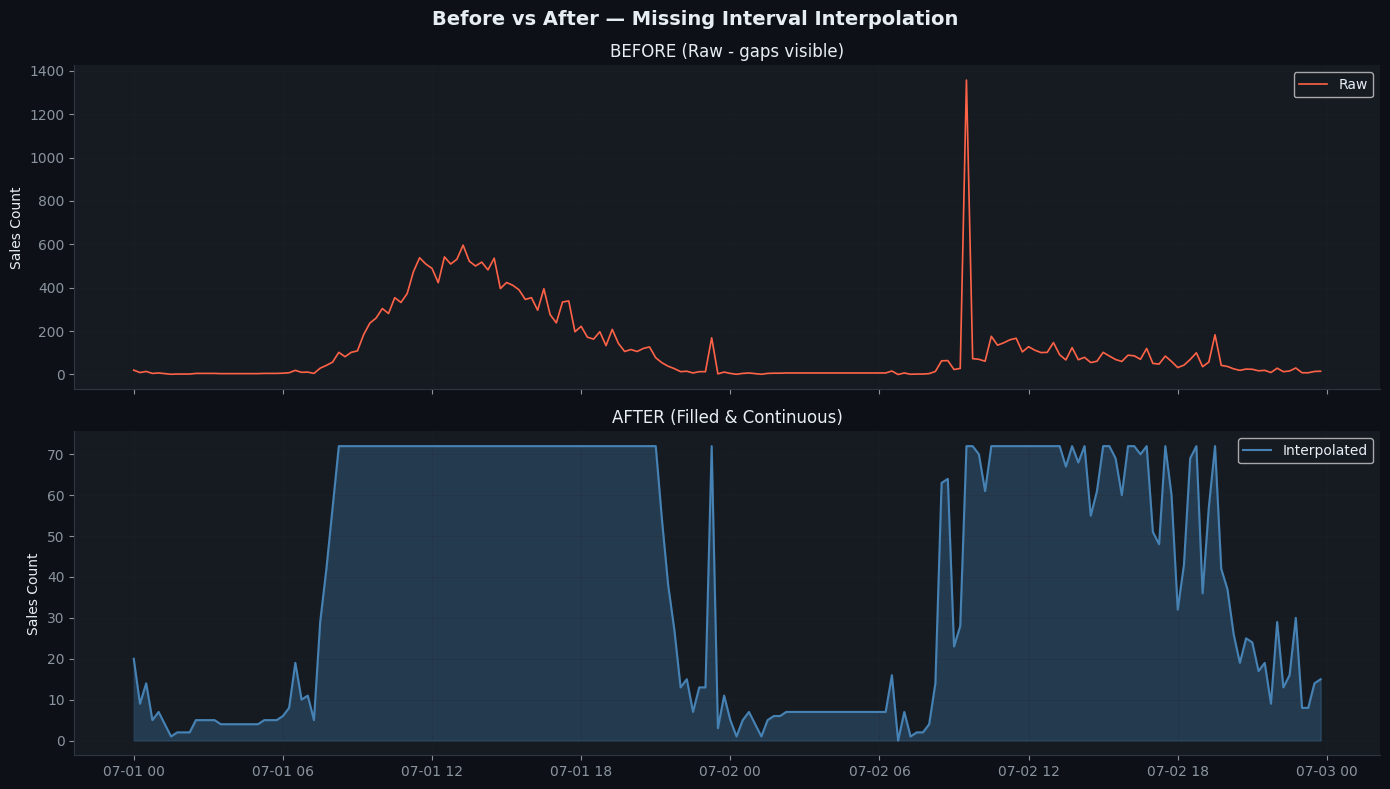

In [18]:
# STEP 3 - SMOOTHING
df['Sales_smooth_1h'] = df['Sales Count'].rolling(window=4, center=True, min_periods=1).mean().round(2)
df['Sales_smooth_2h'] = df['Sales Count'].rolling(window=8, center=True, min_periods=1).mean().round(2)

# ══════════════════════════════════════════════════════
# STEP 4 - ADD TEMPORAL FEATURES
# ══════════════════════════════════════════════════════
df = df.reset_index()
df['Year']      = df['Timestamp'].dt.year
df['Month']     = df['Timestamp'].dt.month
df['Hour']      = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)

# Cyclical encoding
df['Hour_sin']  = np.sin(2 * np.pi * df['Hour']  / 24)
df['Hour_cos']  = np.cos(2 * np.pi * df['Hour']  / 24)
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)

print(f"Final shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}\n")

# ══════════════════════════════════════════════════════
# BEFORE vs AFTER: MISSING INTERVALS
# ══════════════════════════════════════════════════════
week = df[(df['Timestamp'] >= '2019-07-01') & (df['Timestamp'] < '2019-07-03')]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Before vs After — Missing Interval Interpolation', fontsize=14, fontweight='bold')

ax1.plot(week['Timestamp'], week['Sales_raw'], color='tomato', lw=1.2, label='Raw')
ax1.set_title('BEFORE (Raw - gaps visible)')
ax1.set_ylabel('Sales Count')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.fill_between(week['Timestamp'], week['Sales Count'], alpha=0.3, color='steelblue')
ax2.plot(week['Timestamp'], week['Sales Count'], color='steelblue', lw=1.5, label='Interpolated')
ax2.set_title('AFTER (Filled & Continuous)')
ax2.set_ylabel('Sales Count')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


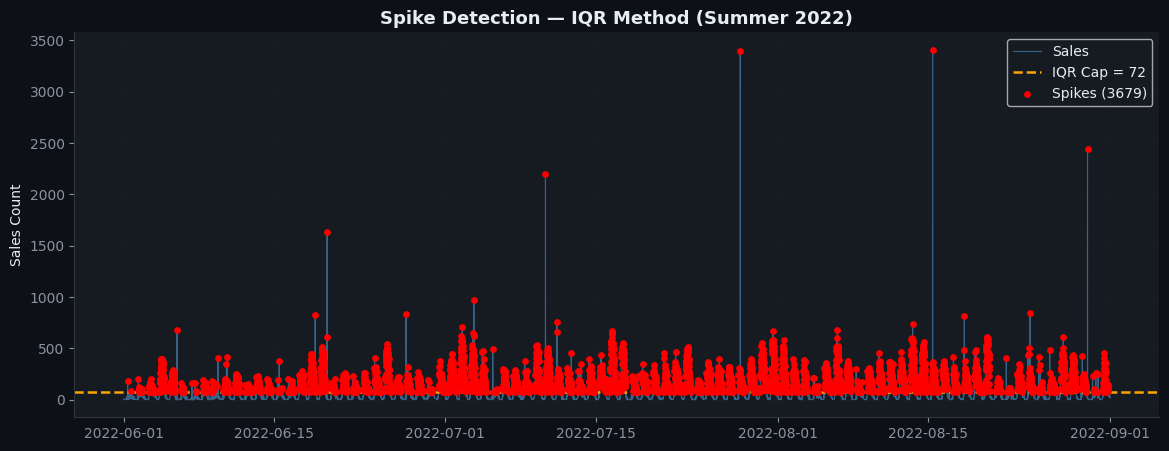

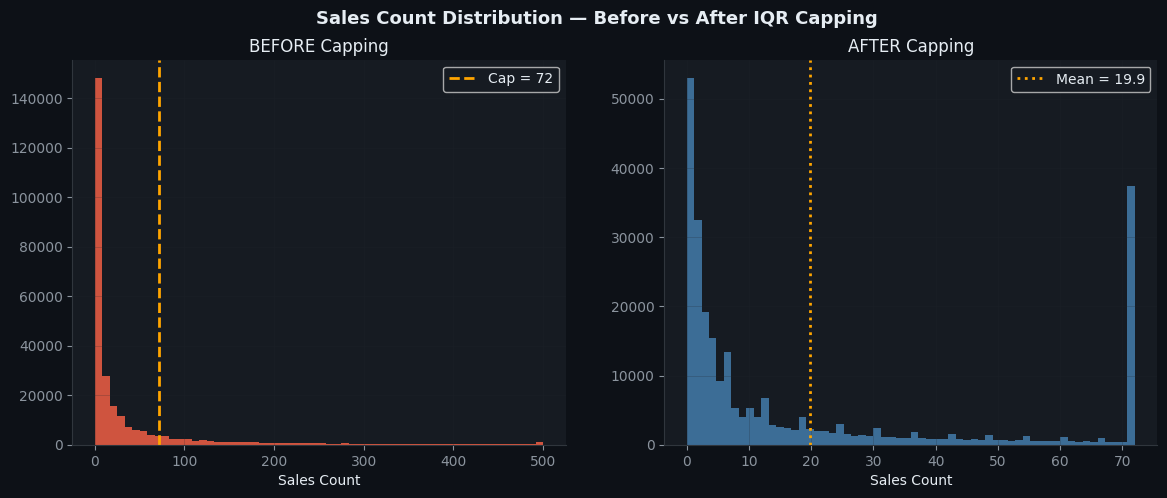

In [19]:
# SPIKE DETECTION (IQR METHOD)
summer = df[(df['Timestamp'] >= '2022-06-01') & (df['Timestamp'] < '2022-09-01')]
spikes = summer[summer['Sales_raw'] > upper_cap]

plt.figure(figsize=(14, 5))
plt.plot(summer['Timestamp'], summer['Sales_raw'], color='steelblue', lw=0.8, alpha=0.7, label='Sales')
plt.axhline(upper_cap, color='orange', lw=1.8, linestyle='--', label=f'IQR Cap = {upper_cap:.0f}')
plt.scatter(spikes['Timestamp'], spikes['Sales_raw'], color='red', s=15, zorder=5, label=f'Spikes ({len(spikes)})')
plt.title('Spike Detection — IQR Method (Summer 2022)', fontsize=13, fontweight='bold')
plt.ylabel('Sales Count')
plt.legend(); plt.grid(alpha=0.3)
# plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════
# FIGURE 3 - BEFORE vs AFTER CAPPING (DISTRIBUTION)
# ══════════════════════════════════════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sales Count Distribution — Before vs After IQR Capping', fontsize=13, fontweight='bold')

ax1.hist(df['Sales_raw'].clip(0, 500), bins=60, color='tomato', alpha=0.8, edgecolor='none')
ax1.axvline(upper_cap, color='orange', lw=2, linestyle='--', label=f'Cap = {upper_cap:.0f}')
ax1.set_title('BEFORE Capping'); ax1.set_xlabel('Sales Count'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.hist(df['Sales Count'], bins=60, color='steelblue', alpha=0.8, edgecolor='none')
ax2.axvline(df['Sales Count'].mean(), color='orange', lw=2, linestyle=':', label=f"Mean = {df['Sales Count'].mean():.1f}")
ax2.set_title('AFTER Capping'); ax2.set_xlabel('Sales Count'); ax2.legend(); ax2.grid(alpha=0.3)

# plt.tight_layout()
plt.show()

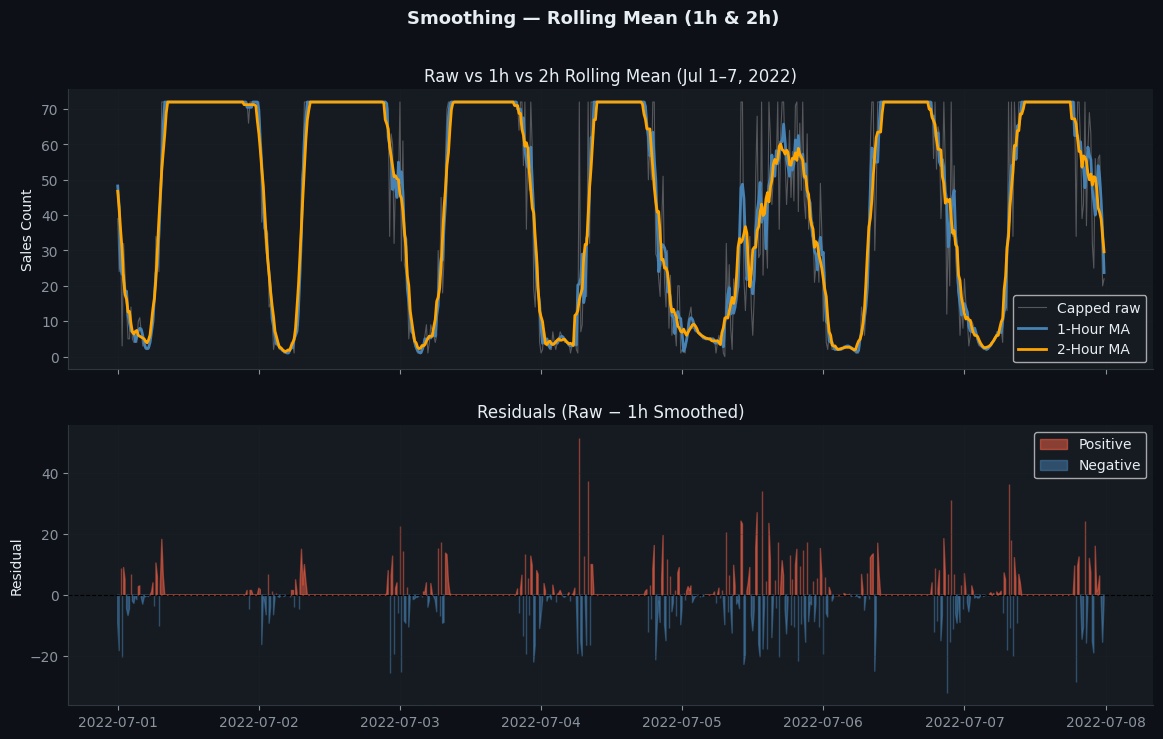

In [20]:
# SMOOTHING EFFECT
w = df[(df['Timestamp'] >= '2022-07-01') & (df['Timestamp'] < '2022-07-08')]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
fig.suptitle('Smoothing — Rolling Mean (1h & 2h)', fontsize=13, fontweight='bold')

ax1.plot(w['Timestamp'], w['Sales Count'],     color='gray',      lw=0.8, alpha=0.6, label='Capped raw')
ax1.plot(w['Timestamp'], w['Sales_smooth_1h'], color='steelblue', lw=2.0, label='1-Hour MA')
ax1.plot(w['Timestamp'], w['Sales_smooth_2h'], color='orange',    lw=2.0, label='2-Hour MA')
ax1.set_title('Raw vs 1h vs 2h Rolling Mean (Jul 1–7, 2022)')
ax1.set_ylabel('Sales Count')
ax1.legend(); ax1.grid(alpha=0.3)

residuals = w['Sales Count'] - w['Sales_smooth_1h']
ax2.fill_between(w['Timestamp'], residuals, alpha=0.5, color='tomato',    where=residuals >= 0, label='Positive')
ax2.fill_between(w['Timestamp'], residuals, alpha=0.5, color='steelblue', where=residuals  < 0, label='Negative')
ax2.axhline(0, color='black', lw=0.8, linestyle='--')
ax2.set_title('Residuals (Raw − 1h Smoothed)')
ax2.set_ylabel('Residual')
ax2.legend(); ax2.grid(alpha=0.3)

# plt.tight_layout()
plt.show()

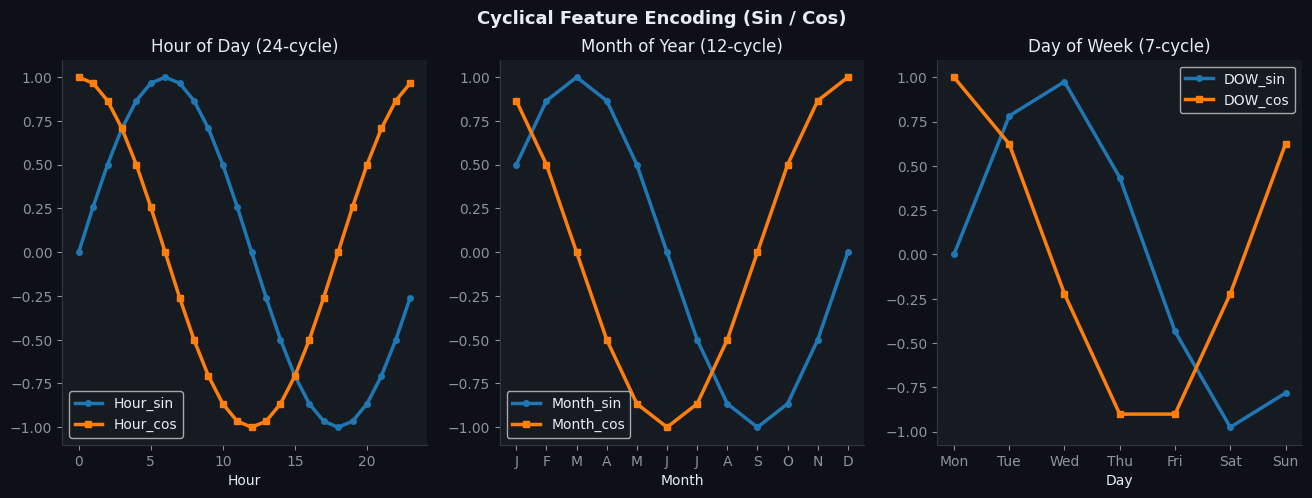

In [21]:
# ══════════════════════════════════════════════════════
# CYCLICAL ENCODING
# ══════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Cyclical Feature Encoding (Sin / Cos)', fontsize=13, fontweight='bold')

hrs = np.arange(24)
axes[0].plot(hrs, np.sin(2*np.pi*hrs/24), lw=2.5, marker='o', ms=4, label='Hour_sin')
axes[0].plot(hrs, np.cos(2*np.pi*hrs/24), lw=2.5, marker='s', ms=4, label='Hour_cos')
axes[0].set_title('Hour of Day (24-cycle)')
axes[0].set_xlabel('Hour')
axes[0].legend(); axes[0].grid(alpha=0.3)

mos = np.arange(1, 13)
axes[1].plot(mos, np.sin(2*np.pi*mos/12), lw=2.5, marker='o', ms=4, label='Month_sin')
axes[1].plot(mos, np.cos(2*np.pi*mos/12), lw=2.5, marker='s', ms=4, label='Month_cos')
axes[1].set_title('Month of Year (12-cycle)')
axes[1].set_xlabel('Month')
axes[1].set_xticks(mos)
axes[1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[1].legend(); axes[1].grid(alpha=0.3)

dows = np.arange(7)
axes[2].plot(dows, np.sin(2*np.pi*dows/7), lw=2.5, marker='o', ms=4, label='DOW_sin')
axes[2].plot(dows, np.cos(2*np.pi*dows/7), lw=2.5, marker='s', ms=4, label='DOW_cos')
axes[2].set_title('Day of Week (7-cycle)')
axes[2].set_xlabel('Day')
axes[2].set_xticks(dows)
axes[2].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
axes[2].legend(); axes[2].grid(alpha=0.3)

# plt.tight_layout()
plt.show()

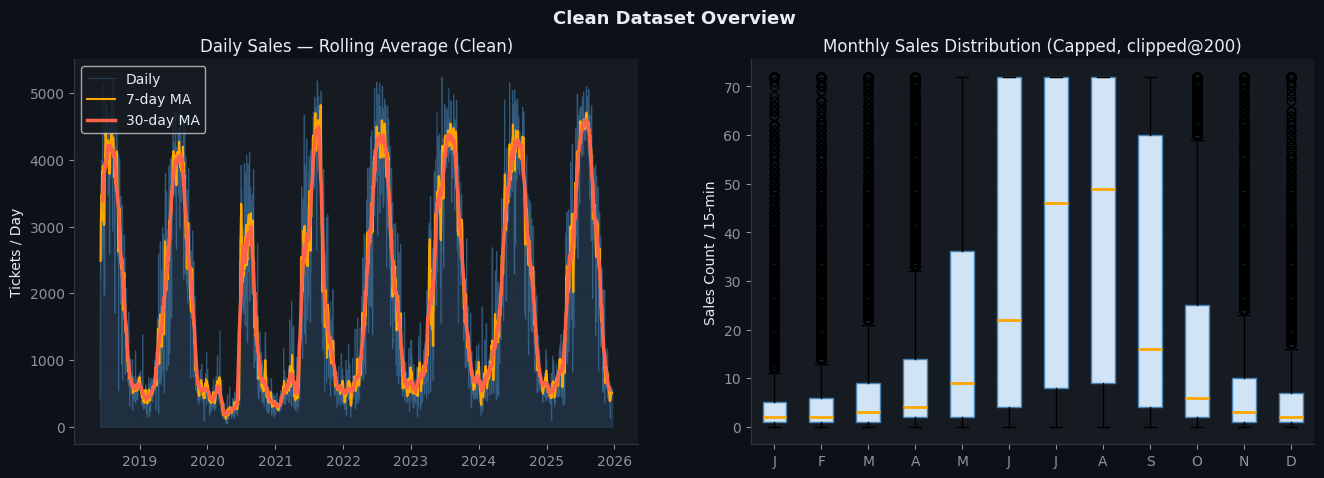

Shape: (264878, 17)


In [22]:
# CLEAN DATASET OVERVIEW
daily = df.groupby(df['Timestamp'].dt.date)[['Sales Count','Redemption Count']].sum().reset_index()
daily.columns = ['Date','Sales','Redemp']
daily['Date'] = pd.to_datetime(daily['Date'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Clean Dataset Overview', fontsize=13, fontweight='bold')

axes[0].fill_between(daily['Date'], daily['Sales'], alpha=0.2, color='steelblue')
axes[0].plot(daily['Date'], daily['Sales'], color='steelblue', lw=0.5, alpha=0.5, label='Daily')
axes[0].plot(daily['Date'], daily['Sales'].rolling(7,  center=True).mean(), color='orange', lw=1.5, label='7-day MA')
axes[0].plot(daily['Date'], daily['Sales'].rolling(30, center=True).mean(), color='tomato',  lw=2.5, label='30-day MA')
axes[0].set_title('Daily Sales — Rolling Average (Clean)')
axes[0].set_ylabel('Tickets / Day')
axes[0].legend(); axes[0].grid(alpha=0.3)

month_groups = [df[df['Month']==m]['Sales Count'].clip(0, 200).values for m in range(1, 13)]
axes[1].boxplot(month_groups, patch_artist=True,
                medianprops=dict(color='orange', lw=2),
                boxprops=dict(facecolor='#d0e4f5', edgecolor='steelblue'))
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(['J','F','M','A','M','J','J','A','S','O','N','D'])
axes[1].set_title('Monthly Sales Distribution (Capped, clipped@200)')
axes[1].set_ylabel('Sales Count / 15-min')
axes[1].grid(alpha=0.3)

# plt.tight_layout()
plt.show()
print(f"Shape: {df.shape}")

# Feature Enginerring
Goal: Build predictive signals for ML models

* **Lag features**: t-1, t-2, t-4, t-8 intervals
* **Rolling stats**: mean, std, max over windows
* **Temporal encodings**: hour, day of week, month, weekend flag
* **Cyclical encoding**: sin/cos for hour & day (for ML models)
* **Train/test split** (time-based, no shuffling)

In [23]:
# STEP 1 - LAG FEATURES
# t-1 = 15 min ago, t-2 = 30 min ago, t-4 = 1 hr ago, t-8 = 2 hrs ago
df['Sales_lag1'] = df['Sales Count'].shift(1)
df['Sales_lag2'] = df['Sales Count'].shift(2)
df['Sales_lag4'] = df['Sales Count'].shift(4)
df['Sales_lag8'] = df['Sales Count'].shift(8)

df['Redemp_lag1'] = df['Redemption Count'].shift(1)
df['Redemp_lag2'] = df['Redemption Count'].shift(2)
df['Redemp_lag4'] = df['Redemption Count'].shift(4)
df['Redemp_lag8'] = df['Redemption Count'].shift(8)
print("Lag features added.")

# ══════════════════════════════════════════════════════
# STEP 2 - ROLLING STATISTICS
# ══════════════════════════════════════════════════════
df['Sales_roll_mean_4']  = df['Sales Count'].rolling(4).mean()    # 1 hr mean
df['Sales_roll_mean_8']  = df['Sales Count'].rolling(8).mean()    # 2 hr mean
df['Sales_roll_std_4']   = df['Sales Count'].rolling(4).std()     # 1 hr std
df['Sales_roll_max_4']   = df['Sales Count'].rolling(4).max()     # 1 hr max

df['Redemp_roll_mean_4'] = df['Redemption Count'].rolling(4).mean()
df['Redemp_roll_std_4']  = df['Redemption Count'].rolling(4).std()
print("Rolling statistics added.")

# ══════════════════════════════════════════════════════
# STEP 3 - SAME TIME YESTERDAY & LAST WEEK
# ══════════════════════════════════════════════════════
df['Sales_same_yesterday'] = df['Sales Count'].shift(96)    # 96 intervals = 24 hrs
df['Sales_same_lastweek']  = df['Sales Count'].shift(672)   # 672 intervals = 7 days
print("Same-time lag features (yesterday, last week) added.")

Lag features added.
Rolling statistics added.
Same-time lag features (yesterday, last week) added.


In [24]:
# STEP 4 - DROP ROWS WITH NaN (from lag/rolling)
df_feat = df.dropna().reset_index(drop=True)

print(f"Shape before dropna : {df.shape}")
print(f"Shape after  dropna : {df_feat.shape}")
print(f"Rows dropped        : {len(df) - len(df_feat)}")
print(f"\nAll columns:\n{df_feat.columns.tolist()}")

# ══════════════════════════════════════════════════════
# STEP 5 - TRAIN / TEST SPLIT (time-based, no shuffle)
# ══════════════════════════════════════════════════════
split_date = '2024-01-01'
train = df_feat[df_feat['Timestamp'] <  split_date].reset_index(drop=True)
test  = df_feat[df_feat['Timestamp'] >= split_date].reset_index(drop=True)

print(f"\nTrain: {train['Timestamp'].min().date()} → {train['Timestamp'].max().date()}  ({len(train):,} rows)")
print(f"Test : {test['Timestamp'].min().date()}  → {test['Timestamp'].max().date()}   ({len(test):,} rows)")

Shape before dropna : (264878, 33)
Shape after  dropna : (191244, 33)
Rows dropped        : 73634

All columns:
['Timestamp', '_id', 'Redemption Count', 'Sales Count', 'Year', 'Month', 'Hour', 'DayOfWeek', 'Date', 'Sales_raw', 'Sales_smooth_1h', 'Sales_smooth_2h', 'IsWeekend', 'Hour_sin', 'Hour_cos', 'Month_sin', 'Month_cos', 'Sales_lag1', 'Sales_lag2', 'Sales_lag4', 'Sales_lag8', 'Redemp_lag1', 'Redemp_lag2', 'Redemp_lag4', 'Redemp_lag8', 'Sales_roll_mean_4', 'Sales_roll_mean_8', 'Sales_roll_std_4', 'Sales_roll_max_4', 'Redemp_roll_mean_4', 'Redemp_roll_std_4', 'Sales_same_yesterday', 'Sales_same_lastweek']

Train: 2018-06-09 → 2023-12-31  (139,377 rows)
Test : 2024-01-01  → 2025-12-21   (51,867 rows)


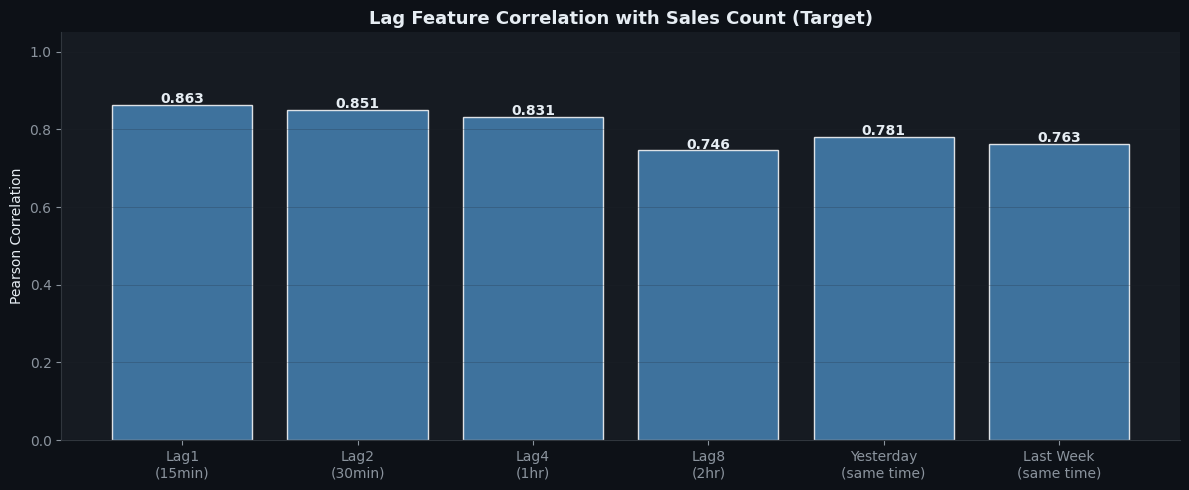

In [25]:
# LAG FEATURE CORRELATION WITH TARGET
lag_cols   = ['Sales_lag1','Sales_lag2','Sales_lag4','Sales_lag8',
              'Sales_same_yesterday','Sales_same_lastweek']
lag_corrs  = [df_feat[c].corr(df_feat['Sales Count']) for c in lag_cols]
lag_labels = ['Lag1\n(15min)','Lag2\n(30min)','Lag4\n(1hr)','Lag8\n(2hr)',
              'Yesterday\n(same time)','Last Week\n(same time)']

plt.figure(figsize=(12, 5))
bars = plt.bar(lag_labels, lag_corrs, color='steelblue', alpha=0.85, edgecolor='white')
for bar, val in zip(bars, lag_corrs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')
plt.axhline(0, color='black', lw=0.8)
plt.title('Lag Feature Correlation with Sales Count (Target)', fontsize=13, fontweight='bold')
plt.ylabel('Pearson Correlation')
plt.ylim(0, 1.05)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


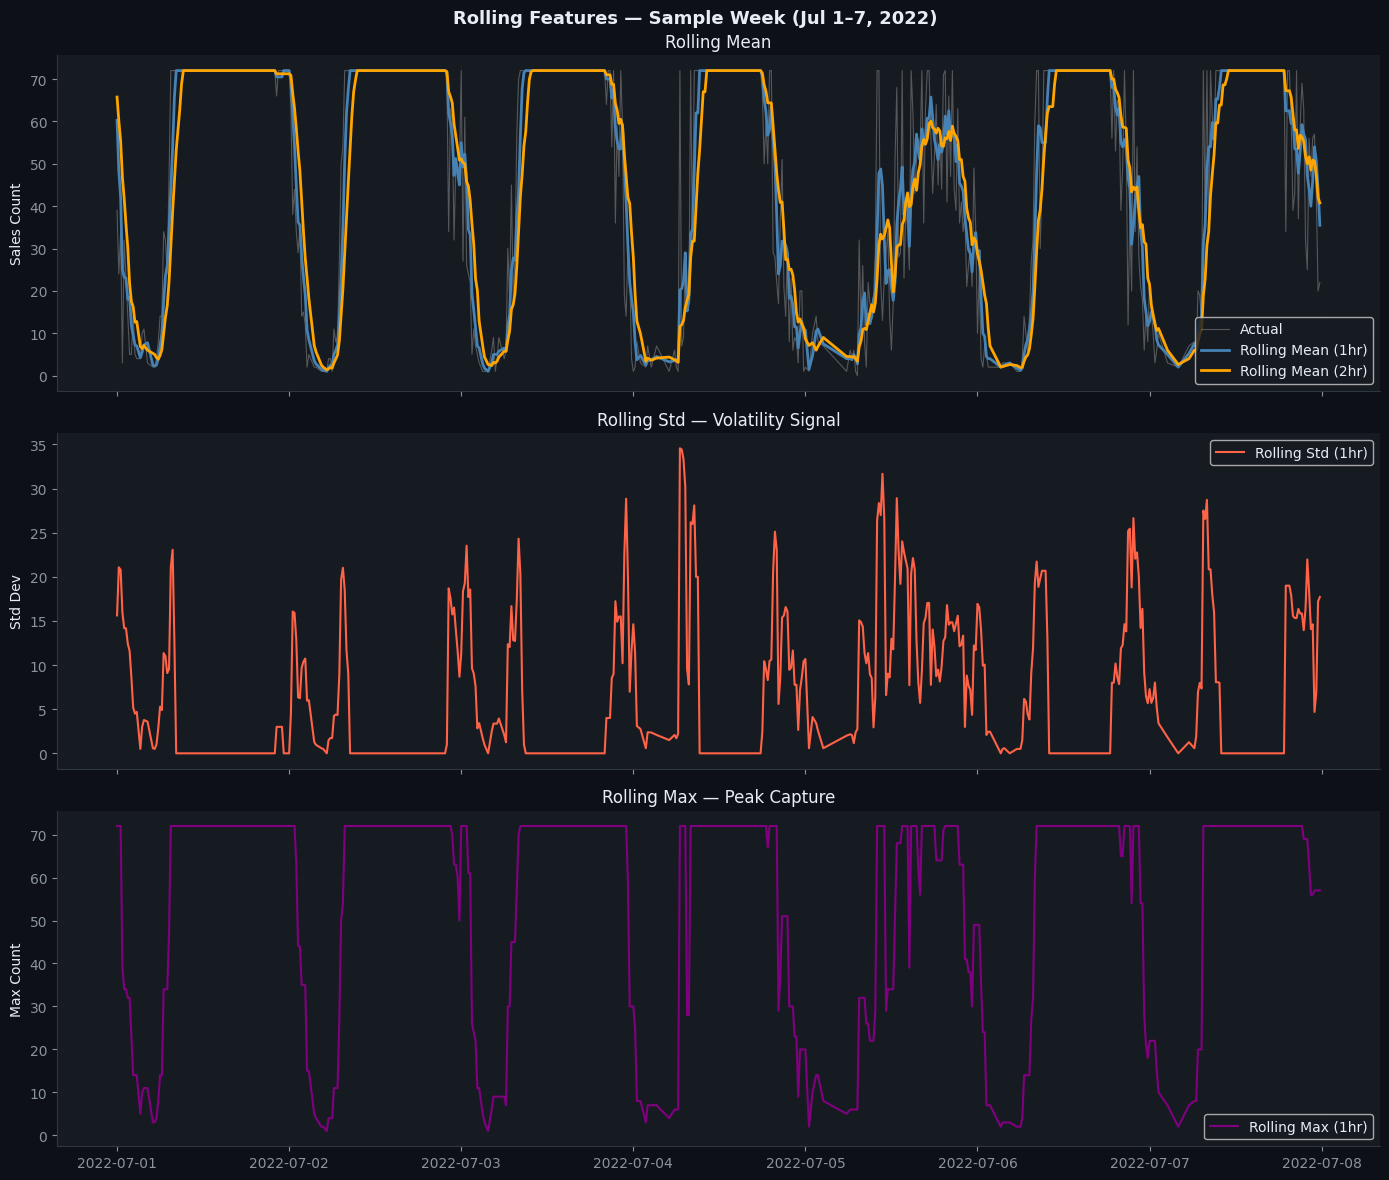

In [26]:
# ROLLING FEATURES OVER A SAMPLE WEEK
w = df_feat[(df_feat['Timestamp'] >= '2022-07-01') &
            (df_feat['Timestamp'] <  '2022-07-08')]

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Rolling Features — Sample Week (Jul 1–7, 2022)', fontsize=13, fontweight='bold')

axes[0].plot(w['Timestamp'], w['Sales Count'],       color='gray',      lw=0.8, alpha=0.6, label='Actual')
axes[0].plot(w['Timestamp'], w['Sales_roll_mean_4'], color='steelblue', lw=2,   label='Rolling Mean (1hr)')
axes[0].plot(w['Timestamp'], w['Sales_roll_mean_8'], color='orange',    lw=2,   label='Rolling Mean (2hr)')
axes[0].set_title('Rolling Mean')
axes[0].set_ylabel('Sales Count')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(w['Timestamp'], w['Sales_roll_std_4'], color='tomato', lw=1.5, label='Rolling Std (1hr)')
axes[1].set_title('Rolling Std — Volatility Signal')
axes[1].set_ylabel('Std Dev')
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(w['Timestamp'], w['Sales_roll_max_4'], color='purple', lw=1.5, label='Rolling Max (1hr)')
axes[2].set_title('Rolling Max — Peak Capture')
axes[2].set_ylabel('Max Count')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

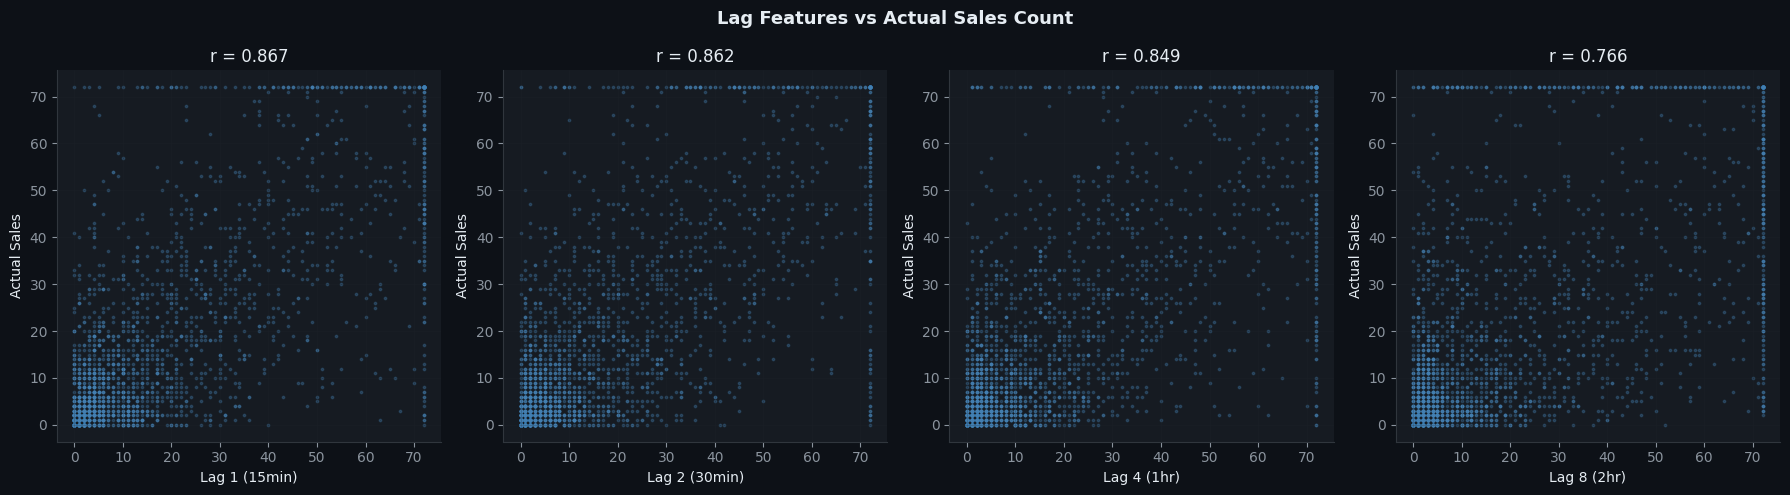

In [27]:
# LAG VALUES vs ACTUAL (SCATTER)
sample = df_feat.sample(3000, random_state=42)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle('Lag Features vs Actual Sales Count', fontsize=13, fontweight='bold')

for ax, col, label in zip(axes,
    ['Sales_lag1','Sales_lag2','Sales_lag4','Sales_lag8'],
    ['Lag 1 (15min)','Lag 2 (30min)','Lag 4 (1hr)','Lag 8 (2hr)']):
    ax.scatter(sample[col], sample['Sales Count'], s=3, alpha=0.3, color='steelblue')
    ax.set_xlabel(label)
    ax.set_ylabel('Actual Sales')
    corr = sample[col].corr(sample['Sales Count'])
    ax.set_title(f'r = {corr:.3f}')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

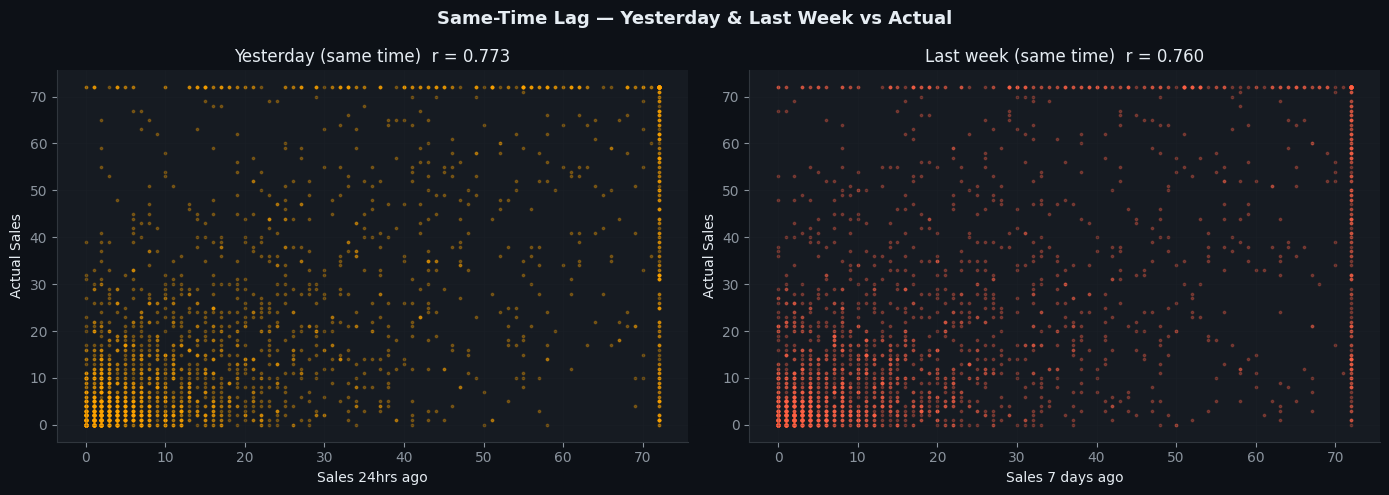

In [28]:
# SAME TIME YESTERDAY vs ACTUAL
s = df_feat.sample(3000, random_state=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Same-Time Lag — Yesterday & Last Week vs Actual', fontsize=13, fontweight='bold')

ax1.scatter(s['Sales_same_yesterday'], s['Sales Count'], s=3, alpha=0.3, color='orange')
r1 = s['Sales_same_yesterday'].corr(s['Sales Count'])
ax1.set_title(f'Yesterday (same time)  r = {r1:.3f}')
ax1.set_xlabel('Sales 24hrs ago')
ax1.set_ylabel('Actual Sales')
ax1.grid(alpha=0.3)

ax2.scatter(s['Sales_same_lastweek'], s['Sales Count'], s=3, alpha=0.3, color='tomato')
r2 = s['Sales_same_lastweek'].corr(s['Sales Count'])
ax2.set_title(f'Last week (same time)  r = {r2:.3f}')
ax2.set_xlabel('Sales 7 days ago')
ax2.set_ylabel('Actual Sales')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

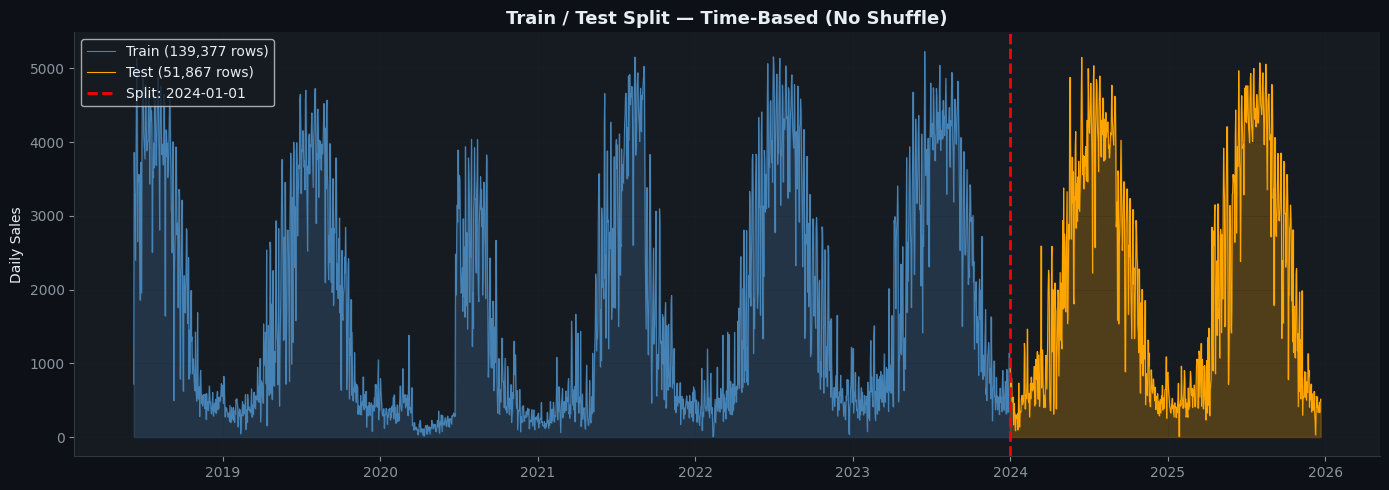

In [29]:
# TRAIN / TEST SPLIT VISUALISATION
train_daily = train.groupby(train['Timestamp'].dt.date)['Sales Count'].sum().reset_index()
test_daily  = test.groupby(test['Timestamp'].dt.date)['Sales Count'].sum().reset_index()
train_daily.columns = ['Date','Sales']
test_daily.columns  = ['Date','Sales']
train_daily['Date'] = pd.to_datetime(train_daily['Date'])
test_daily['Date']  = pd.to_datetime(test_daily['Date'])

plt.figure(figsize=(14, 5))
plt.fill_between(train_daily['Date'], train_daily['Sales'], alpha=0.25, color='steelblue')
plt.plot(train_daily['Date'], train_daily['Sales'], color='steelblue', lw=0.8, label=f'Train ({len(train):,} rows)')
plt.fill_between(test_daily['Date'], test_daily['Sales'], alpha=0.25, color='orange')
plt.plot(test_daily['Date'], test_daily['Sales'], color='orange', lw=0.8, label=f'Test ({len(test):,} rows)')
plt.axvline(pd.Timestamp(split_date), color='red', lw=2, linestyle='--', label=f'Split: {split_date}')
plt.title('Train / Test Split — Time-Based (No Shuffle)', fontsize=13, fontweight='bold')
plt.ylabel('Daily Sales')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


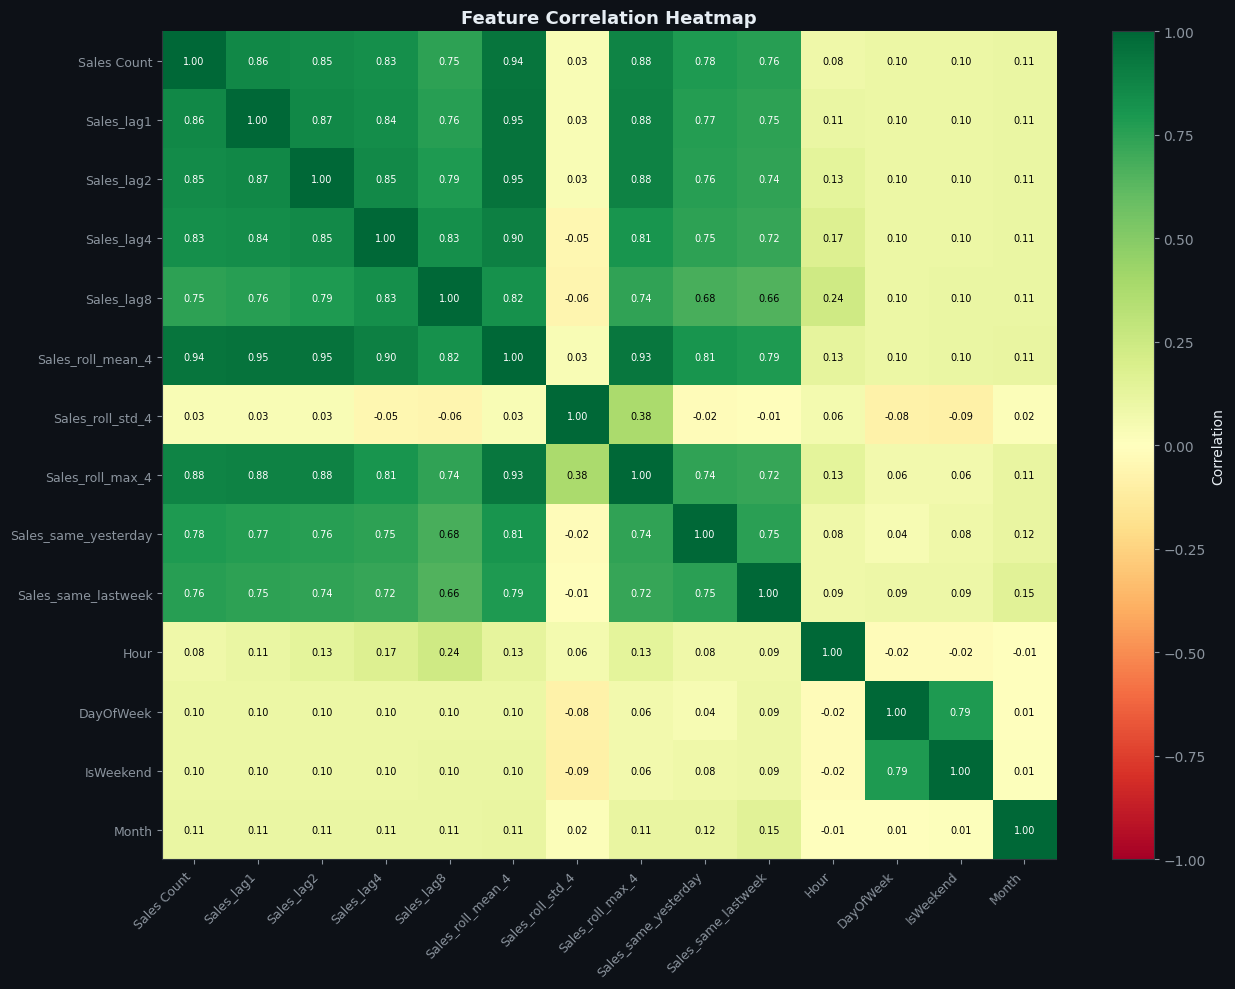

Train shape : (139377, 33)
Test shape  : (51867, 33)


In [30]:
# FEATURE CORRELATION HEATMAP
feat_cols = ['Sales Count','Sales_lag1','Sales_lag2','Sales_lag4','Sales_lag8',
             'Sales_roll_mean_4','Sales_roll_std_4','Sales_roll_max_4',
             'Sales_same_yesterday','Sales_same_lastweek',
             'Hour','DayOfWeek','IsWeekend','Month']

corr_matrix = df_feat[feat_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
im = ax.imshow(corr_matrix.values, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Correlation')
ax.set_xticks(range(len(feat_cols)))
ax.set_xticklabels(feat_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(feat_cols)))
ax.set_yticklabels(feat_cols, fontsize=9)
for i in range(len(feat_cols)):
    for j in range(len(feat_cols)):
        ax.text(j, i, f'{corr_matrix.values[i,j]:.2f}',
                ha='center', va='center', fontsize=7,
                color='black' if abs(corr_matrix.values[i,j]) < 0.7 else 'white')
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Train shape : {train.shape}")
print(f"Test shape  : {test.shape}")

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# ══════════════════════════════════════════════════════
# HELPER - METRICS
# ══════════════════════════════════════════════════════
def get_metrics(actual, predicted, model_name):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    # Only compute MAPE on non-zero actual values
    mask = actual > 0
    mape = np.mean(np.abs((actual[mask] - predicted[mask]) / actual[mask])) * 100

    print(f"\n{model_name}")
    print(f"  MAE  : {mae:.3f}")
    print(f"  RMSE : {rmse:.3f}")
    print(f"  MAPE : {mape:.2f}%")
    return {'Model': model_name, 'MAE': round(mae,3), 'RMSE': round(rmse,3), 'MAPE': round(mape,2)}
results = []

In [32]:
# MODEL 1 - NAIVE FORECAST (last known value)
naive_pred = test['Sales_lag1'].values
actual     = test['Sales Count'].values

results.append(get_metrics(actual, naive_pred,'Naive Forecast'))


Naive Forecast
  MAE  : 8.389
  RMSE : 14.235
  MAPE : 99.08%


In [33]:
# MODEL 2 - MOVING AVERAGE (rolling mean of last 4 = 1hr)
ma_pred = test['Sales_roll_mean_4'].values
results.append(get_metrics(actual, ma_pred, 'Moving Average (1hr)'))


Moving Average (1hr)
  MAE  : 5.754
  RMSE : 9.307
  MAPE : 69.65%


In [34]:
# MODEL 3 - LINEAR REGRESSION WITH LAG FEATURES
feat_cols = ['Sales_lag1','Sales_lag2','Sales_lag4','Sales_lag8',
             'Sales_roll_mean_4','Sales_roll_mean_8',
             'Hour','DayOfWeek','IsWeekend','Month',
             'Hour_sin','Hour_cos','Month_sin','Month_cos']

X_train = train[feat_cols]
y_train = train['Sales Count']
X_test  = test[feat_cols]
y_test  = test['Sales Count']

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_pred = np.clip(lr_pred, 0, None)   # no negative predictions

results.append(get_metrics(y_test.values, lr_pred, 'Linear Regression'))


Linear Regression
  MAE  : 4.692
  RMSE : 7.450
  MAPE : 57.18%


In [35]:
# RESULTS TABLE
results_df = pd.DataFrame(results)
print("\tMODEL COMPARISON TABLE")
print(results_df.to_string(index=False))

	MODEL COMPARISON TABLE
               Model   MAE   RMSE  MAPE
      Naive Forecast 8.389 14.235 99.08
Moving Average (1hr) 5.754  9.307 69.65
   Linear Regression 4.692  7.450 57.18


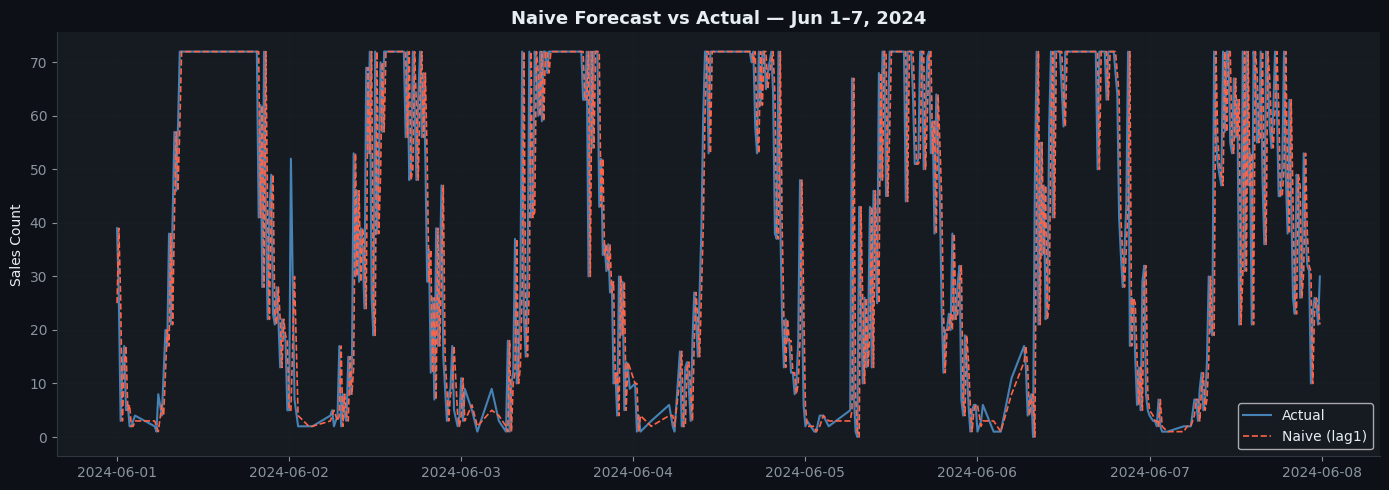

In [36]:
# NAIVE vs ACTUAL (sample week)
w = test[(test['Timestamp'] >= '2024-06-01') &
         (test['Timestamp'] <  '2024-06-08')]

plt.figure(figsize=(14, 5))
plt.plot(w['Timestamp'], w['Sales Count'], color='steelblue', lw=1.5, label='Actual')
plt.plot(w['Timestamp'], w['Sales_lag1'],  color='tomato',    lw=1.2, linestyle='--', label='Naive (lag1)')
plt.title('Naive Forecast vs Actual — Jun 1–7, 2024', fontsize=13, fontweight='bold')
plt.ylabel('Sales Count')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

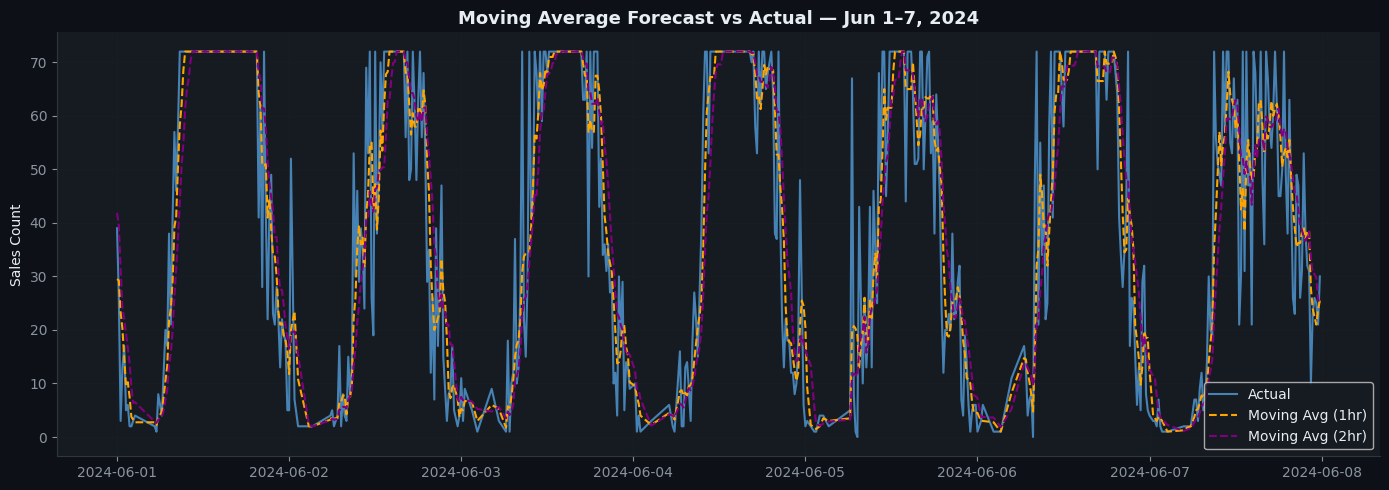

In [37]:
# MOVING AVERAGE vs ACTUAL (sample week)
plt.figure(figsize=(14, 5))
plt.plot(w['Timestamp'], w['Sales Count'],       color='steelblue', lw=1.5, label='Actual')
plt.plot(w['Timestamp'], w['Sales_roll_mean_4'], color='orange',    lw=1.5, linestyle='--', label='Moving Avg (1hr)')
plt.plot(w['Timestamp'], w['Sales_roll_mean_8'], color='purple',    lw=1.5, linestyle='--', label='Moving Avg (2hr)')
plt.title('Moving Average Forecast vs Actual — Jun 1–7, 2024', fontsize=13, fontweight='bold')
plt.ylabel('Sales Count')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

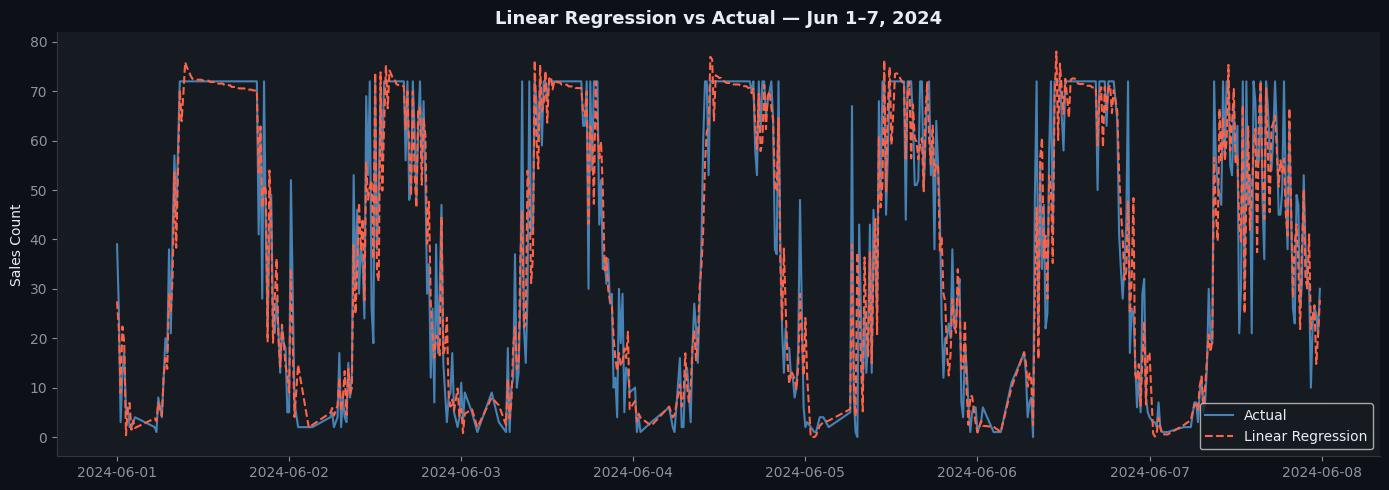

In [38]:
# LINEAR REGRESSION vs ACTUAL (sample week)
w_idx = test[(test['Timestamp'] >= '2024-06-01') &
             (test['Timestamp'] <  '2024-06-08')].index
lr_pred_full = lr.predict(X_test)
lr_pred_full = np.clip(lr_pred_full, 0, None)

plt.figure(figsize=(14, 5))
plt.plot(w['Timestamp'], w['Sales Count'],    color='steelblue', lw=1.5, label='Actual')
plt.plot(w['Timestamp'], lr_pred_full[w_idx - test.index[0]], color='tomato', lw=1.5,
         linestyle='--', label='Linear Regression')
plt.title('Linear Regression vs Actual — Jun 1–7, 2024', fontsize=13, fontweight='bold')
plt.ylabel('Sales Count')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

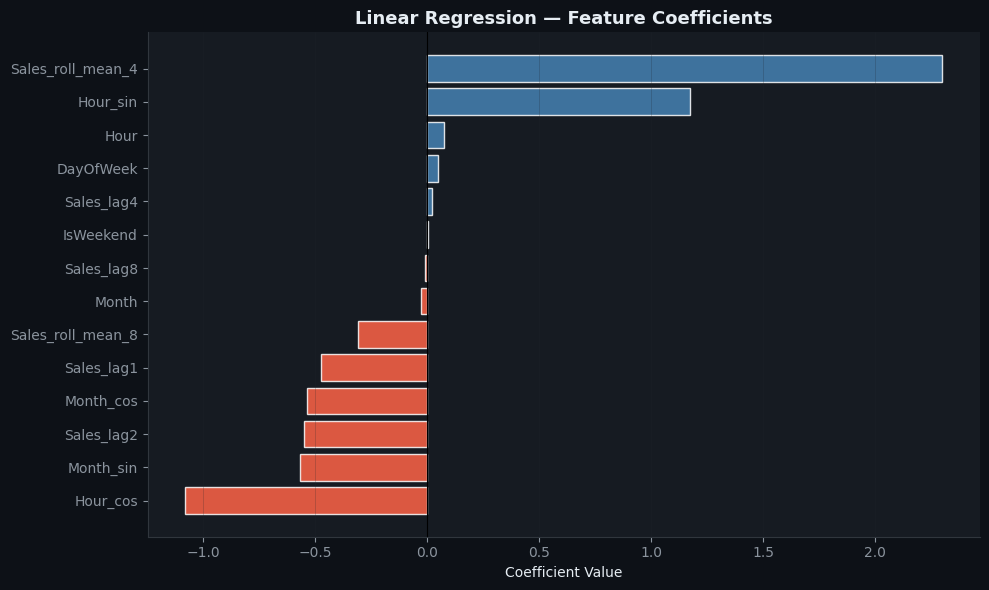

In [39]:
# LINEAR REGRESSION COEFFICIENTS
coef_df = pd.DataFrame({'Feature': feat_cols, 'Coefficient': lr.coef_})
coef_df = coef_df.sort_values('Coefficient', ascending=True)

plt.figure(figsize=(10, 6))
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, alpha=0.85, edgecolor='white')
plt.axvline(0, color='black', lw=0.8)
plt.title('Linear Regression — Feature Coefficients', fontsize=13, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

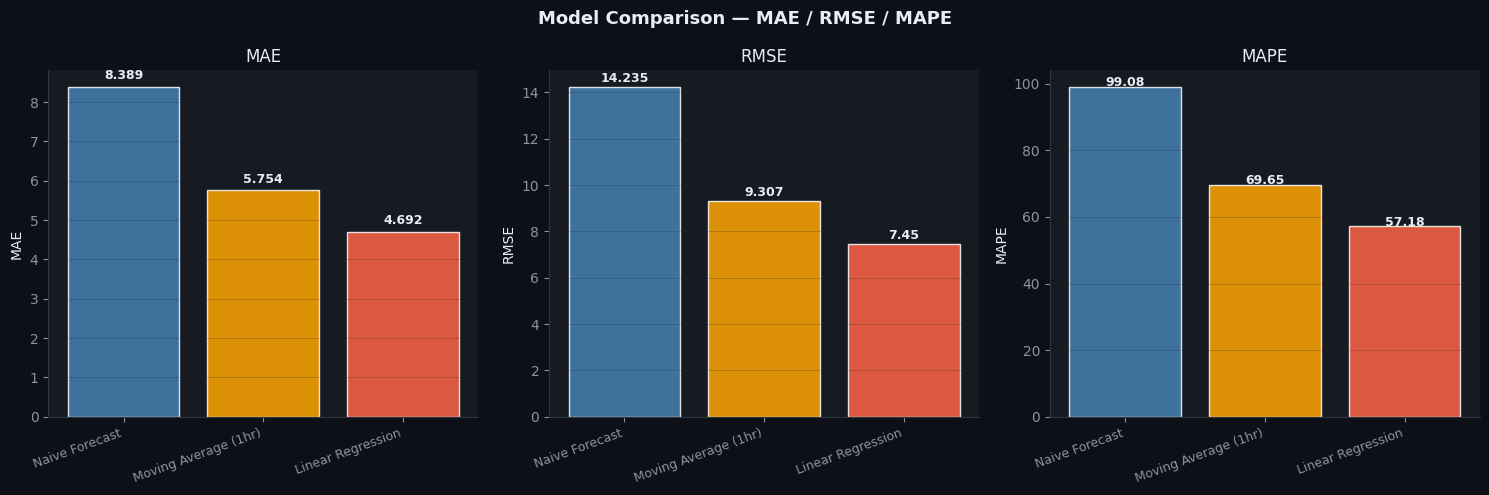

In [40]:
# MODEL COMPARISON BAR CHART
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison — MAE / RMSE / MAPE', fontsize=13, fontweight='bold')

models = results_df['Model'].tolist()
colors = ['steelblue','orange','tomato','purple'][:len(models)]

for ax, metric in zip(axes, ['MAE','RMSE','MAPE']):
    bars = ax.bar(models, results_df[metric], color=colors, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                str(val), ha='center', fontsize=9, fontweight='bold')
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xticklabels(models, rotation=20, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

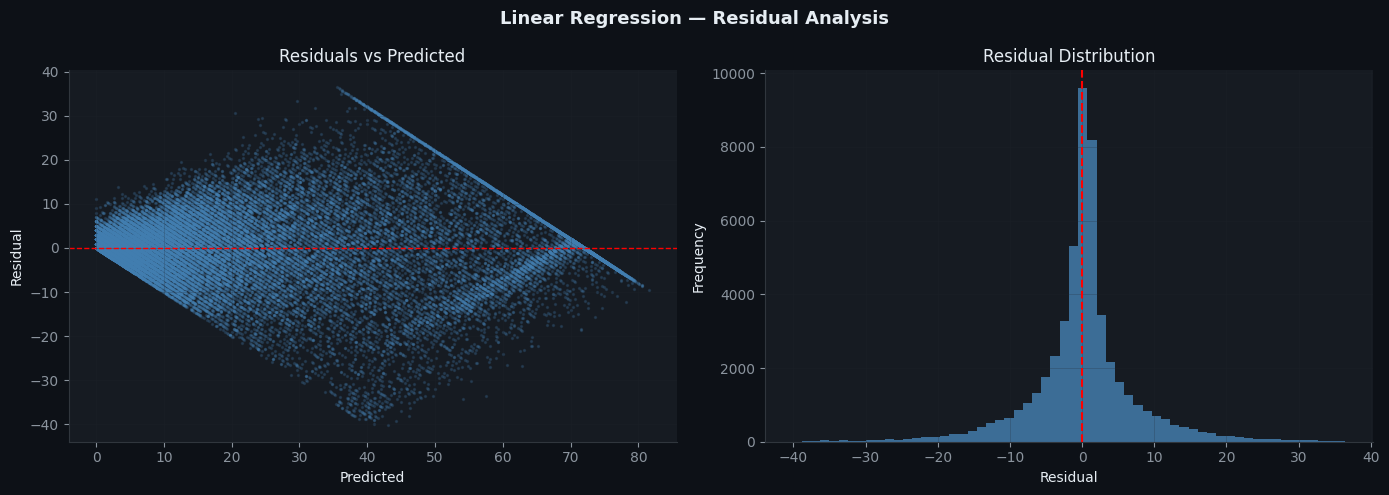

In [41]:
# RESIDUAL PLOT (LINEAR REGRESSION)
residuals = y_test.values - lr_pred_full

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Linear Regression — Residual Analysis', fontsize=13, fontweight='bold')

ax1.scatter(lr_pred_full, residuals, s=2, alpha=0.2, color='steelblue')
ax1.axhline(0, color='red', lw=1, linestyle='--')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Residual')
ax1.set_title('Residuals vs Predicted')
ax1.grid(alpha=0.3)

ax2.hist(residuals, bins=60, color='steelblue', alpha=0.8, edgecolor='none')
ax2.axvline(0, color='red', lw=1.5, linestyle='--')
ax2.set_xlabel('Residual'); ax2.set_ylabel('Frequency')
ax2.set_title('Residual Distribution')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
print(results_df.to_string(index=False))

               Model   MAE   RMSE  MAPE
      Naive Forecast 8.389 14.235 99.08
Moving Average (1hr) 5.754  9.307 69.65
   Linear Regression 4.692  7.450 57.18


In [43]:
# RANDOM FOREST
print("Training Random Forest ...")
rf = RandomForestRegressor(n_estimators=100, max_depth=10,
                           random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_pred = np.clip(rf_pred, 0, None)

rf_result = get_metrics(y_test.values, rf_pred, 'Random Forest')
results.append(rf_result)

Training Random Forest ...

Random Forest
  MAE  : 4.356
  RMSE : 7.374
  MAPE : 51.36%


In [44]:
# MODEL 2 - GRADIENT BOOSTING
print("Training Gradient Boosting ...")
gb = GradientBoostingRegressor(n_estimators=100, max_depth=5,
                                learning_rate=0.1, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_pred = np.clip(gb_pred, 0, None)

gb_result = get_metrics(y_test.values, gb_pred, 'Gradient Boosting')
results.append(gb_result)

Training Gradient Boosting ...

Gradient Boosting
  MAE  : 4.340
  RMSE : 7.250
  MAPE : 50.90%


In [45]:
# MODEL - XGBOOST
try:
    from xgboost import XGBRegressor
    print("Training XGBoost ...")
    xgb = XGBRegressor(n_estimators=100, max_depth=6,
                       learning_rate=0.1, random_state=42,
                       verbosity=0, n_jobs=-1)
    xgb.fit(X_train, y_train)
    xgb_pred = xgb.predict(X_test)
    xgb_pred = np.clip(xgb_pred, 0, None)

    xgb_result = get_metrics(y_test.values, xgb_pred, 'XGBoost')
    results.append(xgb_result)
    xgb_available = True

except ImportError:
    print("XGBoost not installed. Run: pip install xgboost")
    xgb_available = False

Training XGBoost ...

XGBoost
  MAE  : 4.269
  RMSE : 7.212
  MAPE : 49.90%


### MAPE is not the best metric for this dataset because ferry demand has many near-zero intervals (overnight, winter) where even a small absolute error gives a huge percentage error.
### MAE and RMSE are more reliable metrics for this project.


In [46]:
# FULL RESULTS TABLE
results_df = pd.DataFrame(results)
print("\n── FULL MODEL COMPARISON TABLE ──")
print(results_df.to_string(index=False))

# ══════════════════════════════════════════════════════
# SAMPLE WEEK FOR PLOTS
# ══════════════════════════════════════════════════════
w      = test[(test['Timestamp'] >= '2024-06-01') & (test['Timestamp'] < '2024-06-08')]
w_idx  = w.index - test.index[0]
actual = w['Sales Count'].values


── FULL MODEL COMPARISON TABLE ──
               Model   MAE   RMSE  MAPE
      Naive Forecast 8.389 14.235 99.08
Moving Average (1hr) 5.754  9.307 69.65
   Linear Regression 4.692  7.450 57.18
       Random Forest 4.356  7.374 51.36
   Gradient Boosting 4.340  7.250 50.90
             XGBoost 4.269  7.212 49.90


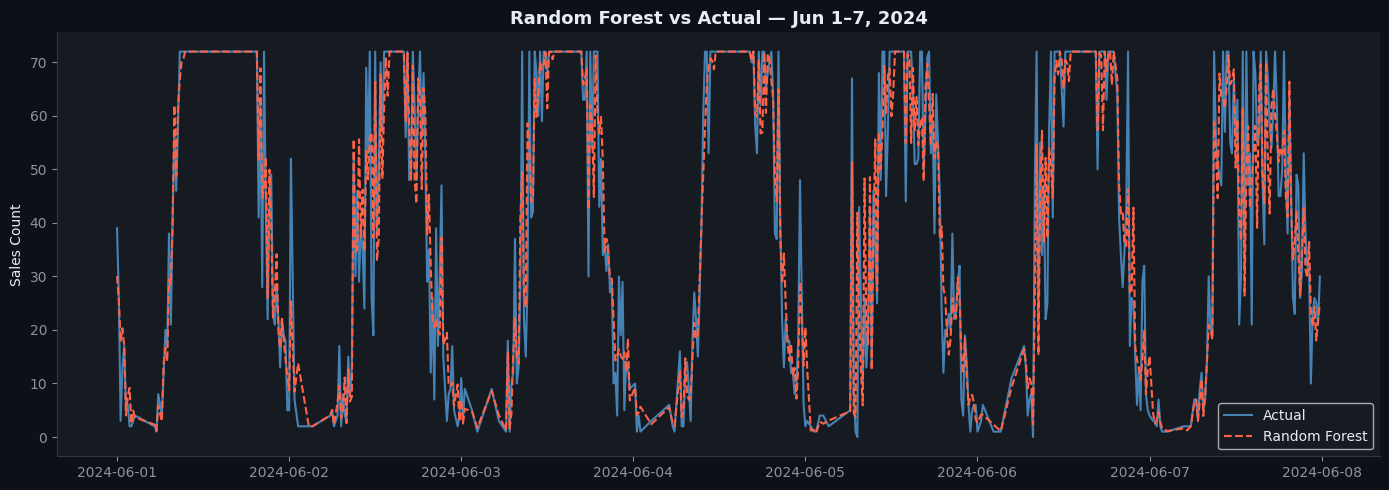

In [47]:
# RANDOM FOREST vs ACTUAL
# ══════════════════════════════════════════════════════
plt.figure(figsize=(14, 5))
plt.plot(w['Timestamp'], actual,          color='steelblue', lw=1.5, label='Actual')
plt.plot(w['Timestamp'], rf_pred[w_idx],  color='tomato',    lw=1.5, linestyle='--', label='Random Forest')
plt.title('Random Forest vs Actual — Jun 1–7, 2024', fontsize=13, fontweight='bold')
plt.ylabel('Sales Count')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

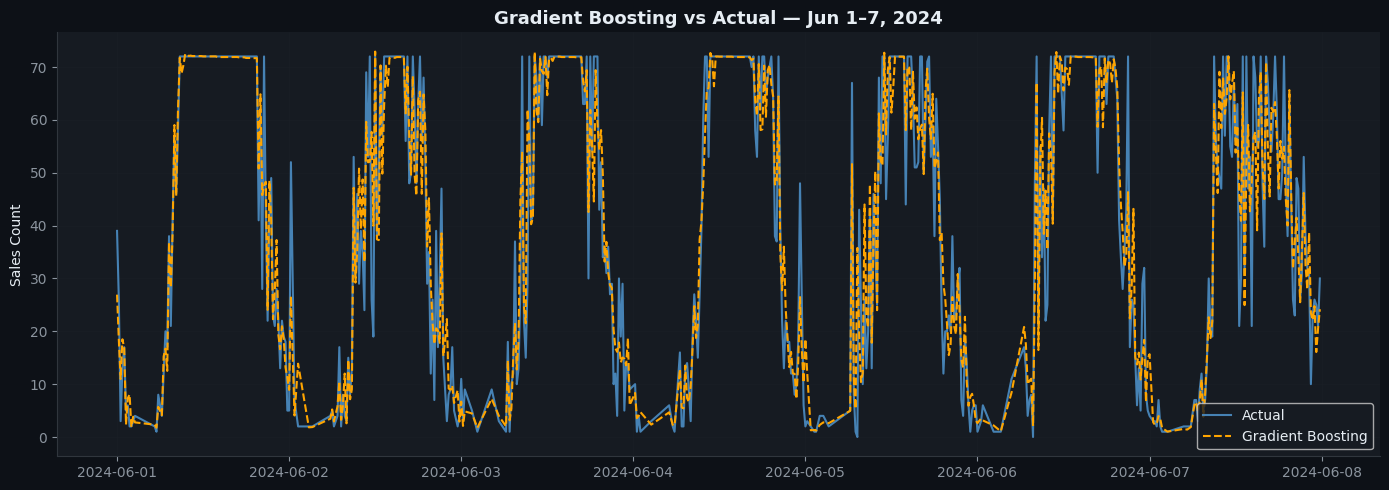

In [48]:
# GRADIENT BOOSTING vs ACTUAL
plt.figure(figsize=(14, 5))
plt.plot(w['Timestamp'], actual,          color='steelblue', lw=1.5, label='Actual')
plt.plot(w['Timestamp'], gb_pred[w_idx],  color='orange',    lw=1.5, linestyle='--', label='Gradient Boosting')
plt.title('Gradient Boosting vs Actual — Jun 1–7, 2024', fontsize=13, fontweight='bold')
plt.ylabel('Sales Count')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

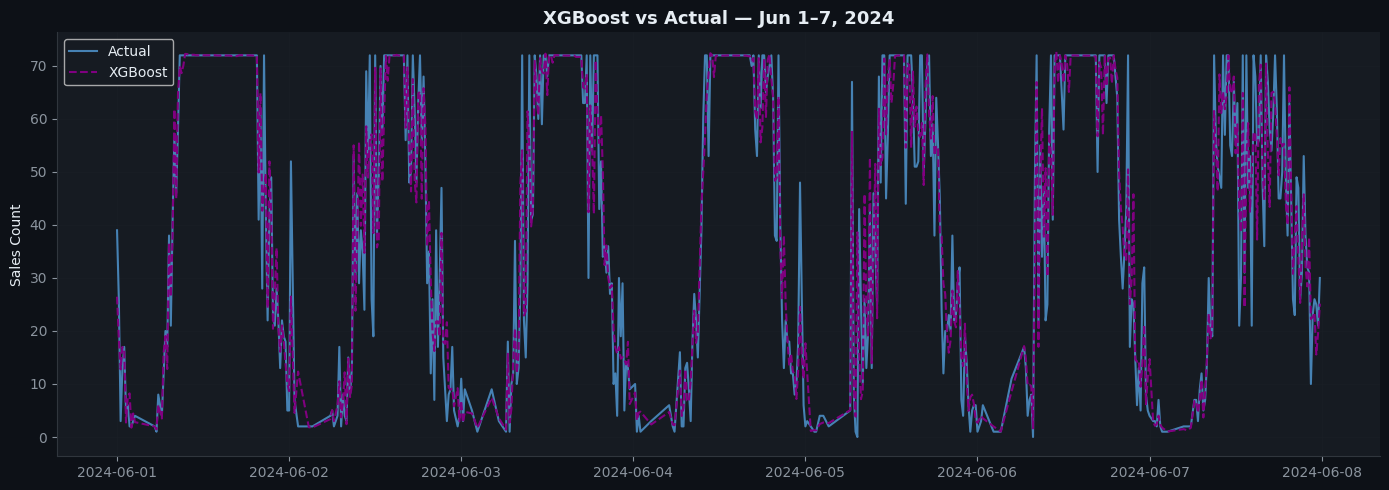

In [49]:
# XGBOOST vs ACTUAL
if xgb_available:
    plt.figure(figsize=(14, 5))
    plt.plot(w['Timestamp'], actual,           color='steelblue', lw=1.5, label='Actual')
    plt.plot(w['Timestamp'], xgb_pred[w_idx],  color='purple',    lw=1.5, linestyle='--', label='XGBoost')
    plt.title('XGBoost vs Actual — Jun 1–7, 2024', fontsize=13, fontweight='bold')
    plt.ylabel('Sales Count')
    plt.legend(); plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

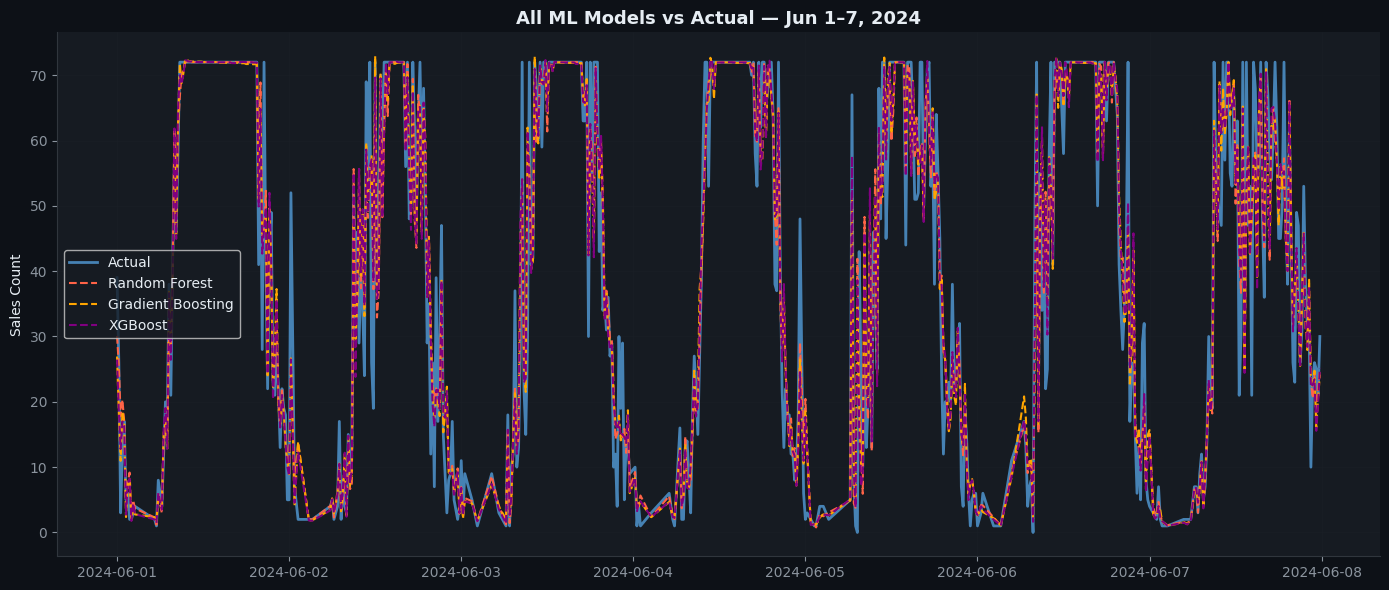

In [50]:
# ALL MODELS vs ACTUAL (one plot)
plt.figure(figsize=(14, 6))
plt.plot(w['Timestamp'], actual,         color='steelblue', lw=2,   label='Actual')
plt.plot(w['Timestamp'], rf_pred[w_idx], color='tomato',    lw=1.5, linestyle='--', label='Random Forest')
plt.plot(w['Timestamp'], gb_pred[w_idx], color='orange',    lw=1.5, linestyle='--', label='Gradient Boosting')
if xgb_available:
    plt.plot(w['Timestamp'], xgb_pred[w_idx], color='purple', lw=1.5, linestyle='--', label='XGBoost')
plt.title('All ML Models vs Actual — Jun 1–7, 2024', fontsize=13, fontweight='bold')
plt.ylabel('Sales Count')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

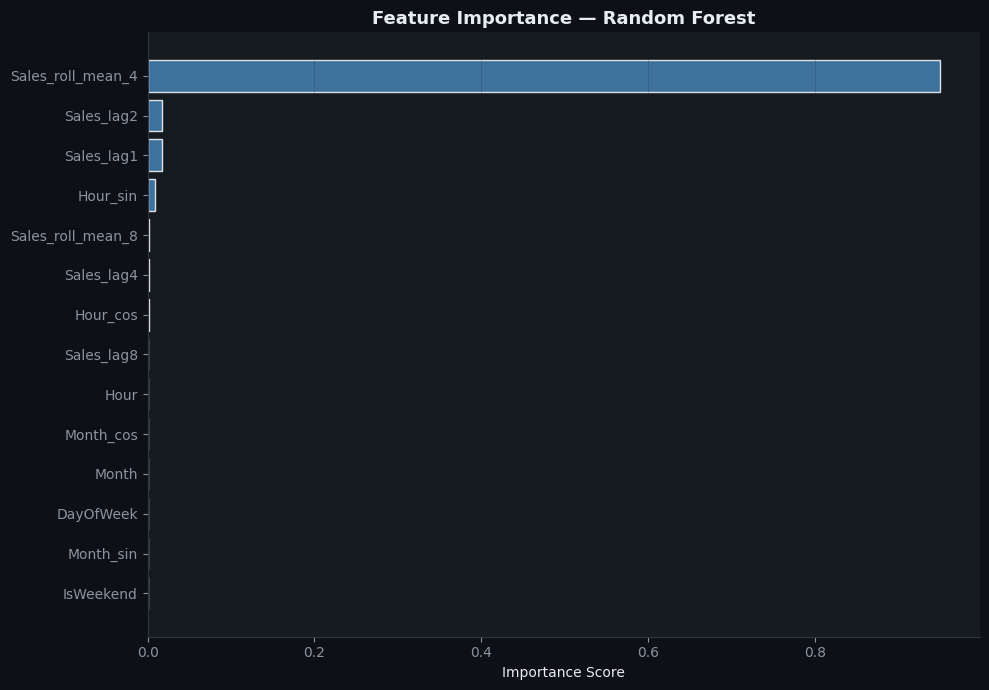

In [51]:
# FEATURE IMPORTANCE (RANDOM FOREST)
fi_rf = pd.DataFrame({'Feature': feat_cols, 'Importance': rf.feature_importances_})
fi_rf = fi_rf.sort_values('Importance', ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(fi_rf['Feature'], fi_rf['Importance'], color='steelblue', alpha=0.85, edgecolor='white')
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

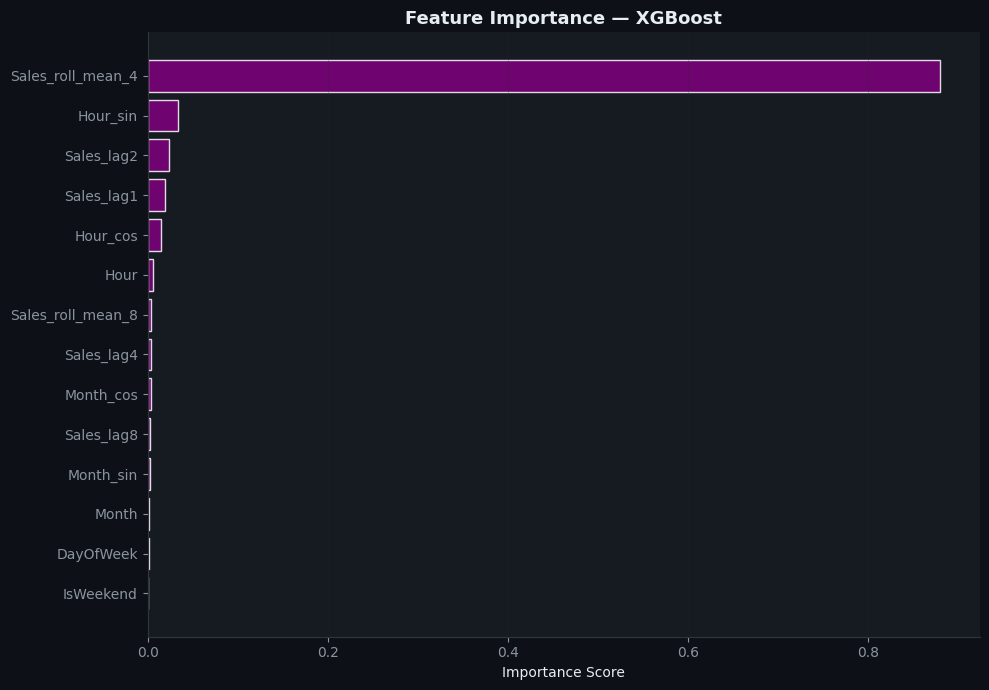

In [52]:
# FEATURE IMPORTANCE (XGBOOST)
if xgb_available:
    fi_xgb = pd.DataFrame({'Feature': feat_cols, 'Importance': xgb.feature_importances_})
    fi_xgb = fi_xgb.sort_values('Importance', ascending=True)

    plt.figure(figsize=(10, 7))
    plt.barh(fi_xgb['Feature'], fi_xgb['Importance'], color='purple', alpha=0.85, edgecolor='white')
    plt.title('Feature Importance — XGBoost', fontsize=13, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

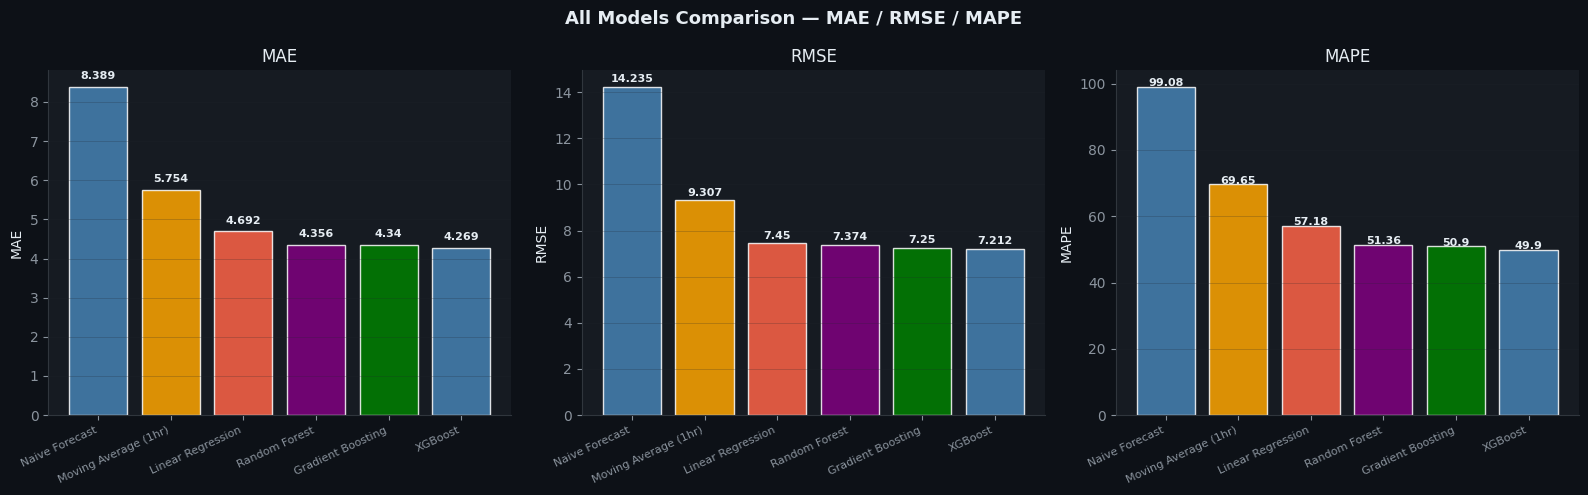

In [53]:
# FULL MODEL COMPARISON (MAE / RMSE / MAPE)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('All Models Comparison — MAE / RMSE / MAPE', fontsize=13, fontweight='bold')

colors = ['steelblue','orange','tomato','purple','green'][:len(results_df)]

for ax, metric in zip(axes, ['MAE','RMSE','MAPE']):
    bars = ax.bar(results_df['Model'], results_df[metric],
                  color=colors, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                str(val), ha='center', fontsize=8, fontweight='bold')
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xticklabels(results_df['Model'], rotation=25, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()



Best model by MAE: XGBoost


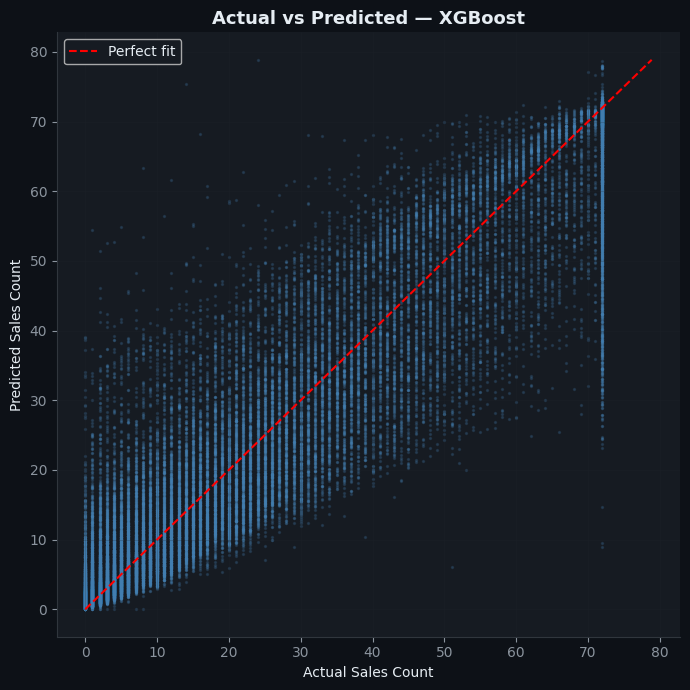

               Model   MAE   RMSE  MAPE
      Naive Forecast 8.389 14.235 99.08
Moving Average (1hr) 5.754  9.307 69.65
   Linear Regression 4.692  7.450 57.18
       Random Forest 4.356  7.374 51.36
   Gradient Boosting 4.340  7.250 50.90
             XGBoost 4.269  7.212 49.90


In [54]:
# SCATTER ACTUAL vs PREDICTED (BEST MODEL)
# Pick best model by MAE
best_name = results_df.loc[results_df['MAE'].idxmin(), 'Model']
if 'XGBoost' in best_name and xgb_available:
    best_pred = xgb_pred
elif 'Random Forest' in best_name:
    best_pred = rf_pred
else:
    best_pred = gb_pred

print(f"\nBest model by MAE: {best_name}")

plt.figure(figsize=(7, 7))
plt.scatter(y_test.values, best_pred, s=2, alpha=0.2, color='steelblue')
max_val = max(y_test.values.max(), best_pred.max())
plt.plot([0, max_val], [0, max_val], color='red', lw=1.5, linestyle='--', label='Perfect fit')
plt.title(f'Actual vs Predicted — {best_name}', fontsize=13, fontweight='bold')
plt.xlabel('Actual Sales Count')
plt.ylabel('Predicted Sales Count')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(results_df.to_string(index=False))

#  Uncertainty Quantification & Model Comparison
Goal: Make forecasts trustworthy for operators

* Prediction intervals (conformal prediction / quantile regression)
* Error bands visualization per model
* Head-to-head model comparison dashboard (MAE, RMSE, MAPE table)
* KPI report: Forecast Accuracy %, Peak Miss Rate, Confidence Band Width
* Select best model per horizon

In [56]:
# STEP 1 - RF PREDICTION INTERVALS
print("Computing prediction intervals from Random Forest trees ...")

tree_preds = np.array([tree.predict(X_test) for tree in rf.estimators_])

rf_mean = tree_preds.mean(axis=0)

# Use actual residuals to calibrate the interval instead of 1.96 * std
residuals_train = y_train.values - rf.predict(X_train)
residual_std    = residuals_train.std()

# Find the multiplier that gives ~95% coverage on train residuals
lower_q = np.percentile(residuals_train, 2.5)
upper_q = np.percentile(residuals_train, 97.5)

rf_lower = np.clip(rf_mean + lower_q, 0, None)
rf_upper = rf_mean + upper_q

# To correctly calculate coverage for the entire test set, ensure 'actual' refers to y_test
actual = y_test.values
rf_coverage = np.mean((actual >= rf_lower) & (actual <= rf_upper)) * 100
print(f"RF interval coverage : {rf_coverage:.1f}%  (target ~95%)")

Computing prediction intervals from Random Forest trees ...
RF interval coverage : 93.6%  (target ~95%)


In [57]:
# STEP 2 - QUANTILE PREDICTION INTERVALS (GRADIENT BOOSTING)
# Train separate models for lower and upper quantiles
from sklearn.ensemble import GradientBoostingRegressor

print("Training quantile models for Gradient Boosting ...")

gb_lower_model = GradientBoostingRegressor(loss='quantile', alpha=0.025,
                                           n_estimators=100, max_depth=5,
                                           learning_rate=0.1, random_state=42)
gb_upper_model = GradientBoostingRegressor(loss='quantile', alpha=0.975,
                                           n_estimators=100, max_depth=5,
                                           learning_rate=0.1, random_state=42)

gb_lower_model.fit(X_train, y_train)
gb_upper_model.fit(X_train, y_train)

gb_lower = np.clip(gb_lower_model.predict(X_test), 0, None)
gb_upper = gb_upper_model.predict(X_test)

print(f"Avg GB confidence band width: {(gb_upper - gb_lower).mean():.2f}")


Training quantile models for Gradient Boosting ...
Avg GB confidence band width: 42.49


In [58]:
# STEP 3 - COVERAGE CHECK
# What % of actual values fall inside the interval
actual = y_test.values

rf_coverage = np.mean((actual >= rf_lower) & (actual <= rf_upper)) * 100
gb_coverage = np.mean((actual >= gb_lower) & (actual <= gb_upper)) * 100

print(f"RF  interval coverage : {rf_coverage:.1f}%  (target ~95%)")
print(f"GB  interval coverage : {gb_coverage:.1f}%  (target ~95%)")

RF  interval coverage : 93.6%  (target ~95%)
GB  interval coverage : 98.2%  (target ~95%)


In [59]:
# STEP 4 - HORIZON-WISE ERROR (15min, 30min, 1hr, 2hr)
# Evaluate how error grows with forecast horizon
print("\nComputing horizon-wise errors ...")

horizons    = [1, 2, 4, 8]
horizon_lbl = ['15 min','30 min','1 hour','2 hours']

horizon_results = []
for h, lbl in zip(horizons, horizon_lbl):
    lag_col = f'Sales_lag{h}'
    if lag_col in test.columns:
        pred  = test[lag_col].values
        act   = test['Sales Count'].values
        mae   = mean_absolute_error(act, pred)
        rmse  = np.sqrt(mean_squared_error(act, pred))
        horizon_results.append({'Horizon': lbl, 'MAE': round(mae,2), 'RMSE': round(rmse,2)})

horizon_df = pd.DataFrame(horizon_results)
print("Horizon-wise Naive Error (baseline drift):")
print(horizon_df.to_string(index=False))


Computing horizon-wise errors ...

Horizon-wise Naive Error (baseline drift):
Horizon   MAE  RMSE
 15 min  8.39 14.24
 30 min  8.82 14.80
 1 hour  9.61 15.98
2 hours 12.42 20.04


In [62]:
# STEP 5 - KPI SUMMARY TABLE
results_df = pd.DataFrame(results)
best_model = results_df.loc[results_df['MAE'].idxmin(), 'Model']
best_mae   = results_df.loc[results_df['MAE'].idxmin(), 'MAE']
best_rmse  = results_df.loc[results_df['MAE'].idxmin(), 'RMSE']
best_mape  = results_df.loc[results_df['MAE'].idxmin(), 'MAPE']
mean_demand  = y_test.mean()
# Determine the predictions from the best model (already calculated in a previous cell)
# Assuming best_pred holds the predictions for the best model from `jOvlqWHIN9KP`

# Ensure actual refers to the full test set actuals
actual_full_test = y_test.values

mae          = mean_absolute_error(actual_full_test, best_pred)
forecast_acc = round((1 - mae / mean_demand) * 100, 2)
print(f"── KPI SUMMARY ──")
print(f"Best Model          : {best_model}")
print(f"Forecast Accuracy   : {forecast_acc}%")
print(f"MAE                 : {best_mae}")
print(f"RMSE                : {best_rmse}")
print(f"RF Coverage (95% CI): {rf_coverage:.1f}%")
print(f"GB Coverage (95% CI): {gb_coverage:.1f}%")

── KPI SUMMARY ──
Best Model          : XGBoost
Forecast Accuracy   : 85.36%
MAE                 : 4.269
RMSE                : 7.212
RF Coverage (95% CI): 93.6%
GB Coverage (95% CI): 98.2%


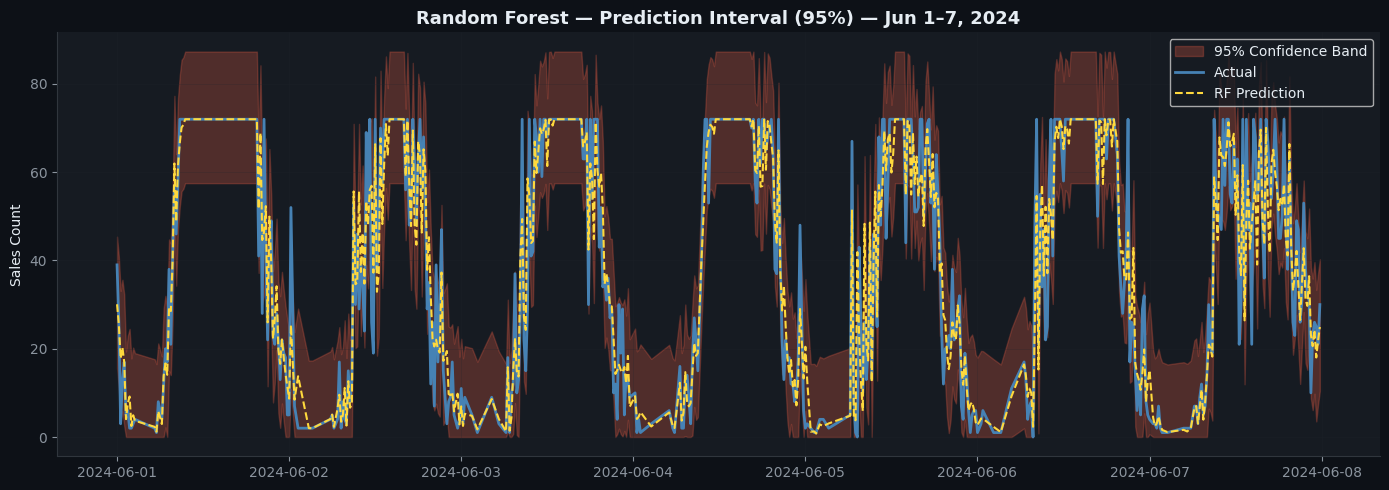

In [63]:
# RF PREDICTION INTERVAL (SAMPLE WEEK)
w = test[(test['Timestamp'] >= '2024-06-01') & (test['Timestamp'] < '2024-06-08')]
w_idx = w.index - test.index[0]

plt.figure(figsize=(14, 5))
plt.fill_between(w['Timestamp'], rf_lower[w_idx], rf_upper[w_idx],
                 alpha=0.25, color='tomato', label='95% Confidence Band')
plt.plot(w['Timestamp'], w['Sales Count'],  color='steelblue', lw=2,   label='Actual')
plt.plot(w['Timestamp'], rf_mean[w_idx],    color=ACCENT3,    lw=1.5, linestyle='--', label='RF Prediction')
plt.title('Random Forest — Prediction Interval (95%) — Jun 1–7, 2024',
          fontsize=13, fontweight='bold')
plt.ylabel('Sales Count')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

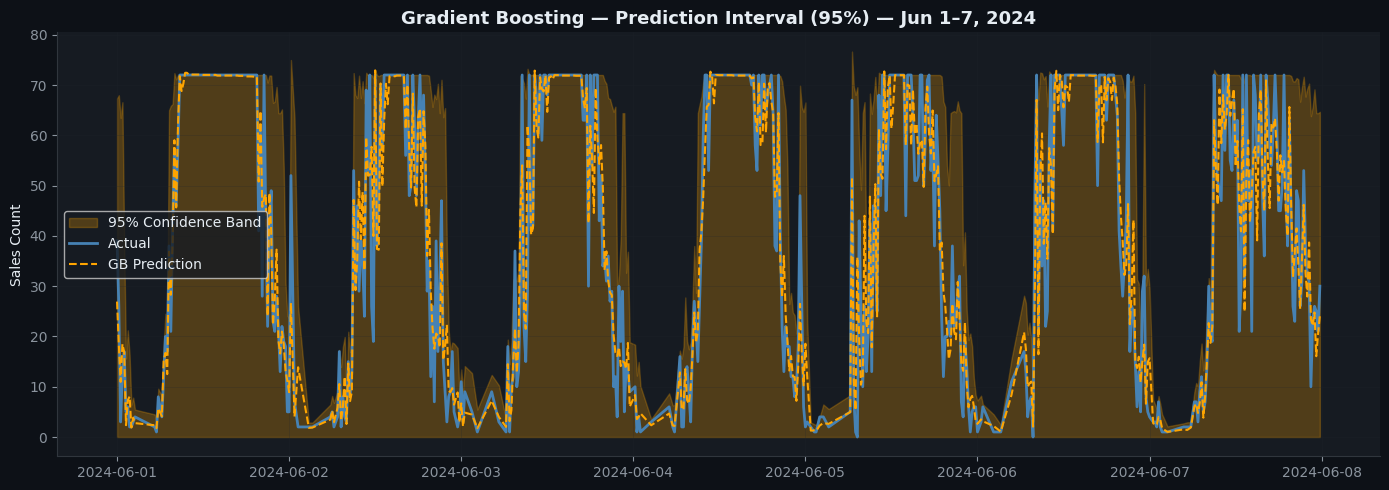

In [64]:
# GB PREDICTION INTERVAL (SAMPLE WEEK)
plt.figure(figsize=(14, 5))
plt.fill_between(w['Timestamp'], gb_lower[w_idx], gb_upper[w_idx],
                 alpha=0.25, color='orange', label='95% Confidence Band')
plt.plot(w['Timestamp'], w['Sales Count'],  color='steelblue', lw=2,   label='Actual')
plt.plot(w['Timestamp'], gb_pred[w_idx],    color='orange',    lw=1.5, linestyle='--', label='GB Prediction')
plt.title('Gradient Boosting — Prediction Interval (95%) — Jun 1–7, 2024',
          fontsize=13, fontweight='bold')
plt.ylabel('Sales Count')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

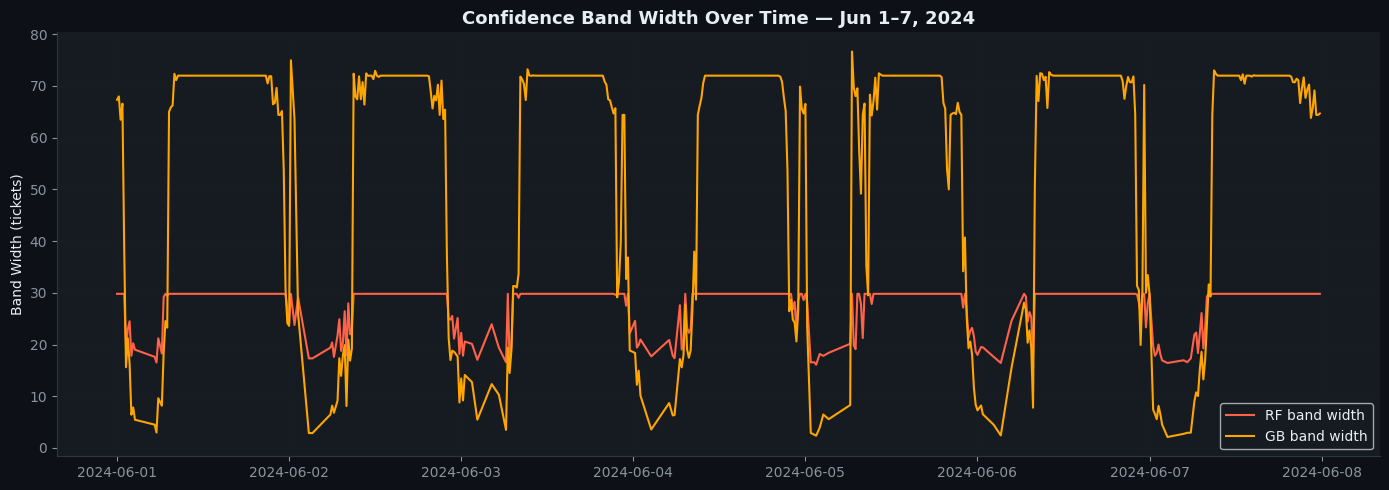

In [65]:
# CONFIDENCE BAND WIDTH OVER TIME
plt.figure(figsize=(14, 5))
plt.plot(w['Timestamp'], (rf_upper - rf_lower)[w_idx], color='tomato',  lw=1.5, label='RF band width')
plt.plot(w['Timestamp'], (gb_upper - gb_lower)[w_idx], color='orange',  lw=1.5, label='GB band width')
plt.title('Confidence Band Width Over Time — Jun 1–7, 2024',
          fontsize=13, fontweight='bold')
plt.ylabel('Band Width (tickets)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

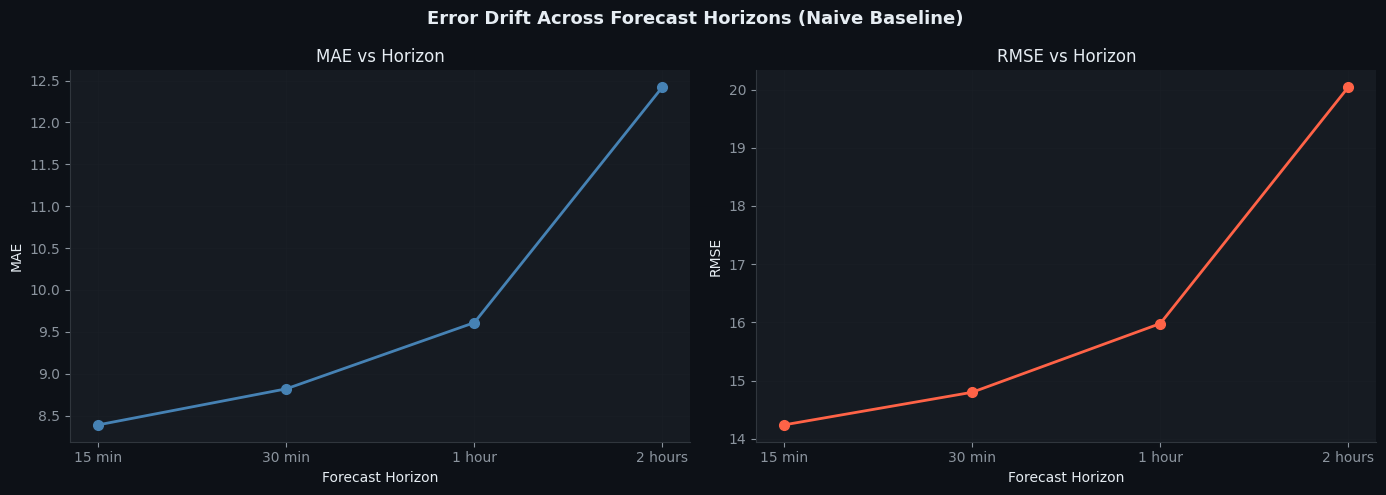

In [66]:
# HORIZON-WISE ERROR DRIFT
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Error Drift Across Forecast Horizons (Naive Baseline)',
             fontsize=13, fontweight='bold')

ax1.plot(horizon_df['Horizon'], horizon_df['MAE'],  color='steelblue', lw=2, marker='o', ms=7)
ax1.set_title('MAE vs Horizon')
ax1.set_ylabel('MAE')
ax1.set_xlabel('Forecast Horizon')
ax1.grid(alpha=0.3)

ax2.plot(horizon_df['Horizon'], horizon_df['RMSE'], color='tomato', lw=2, marker='o', ms=7)
ax2.set_title('RMSE vs Horizon')
ax2.set_ylabel('RMSE')
ax2.set_xlabel('Forecast Horizon')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

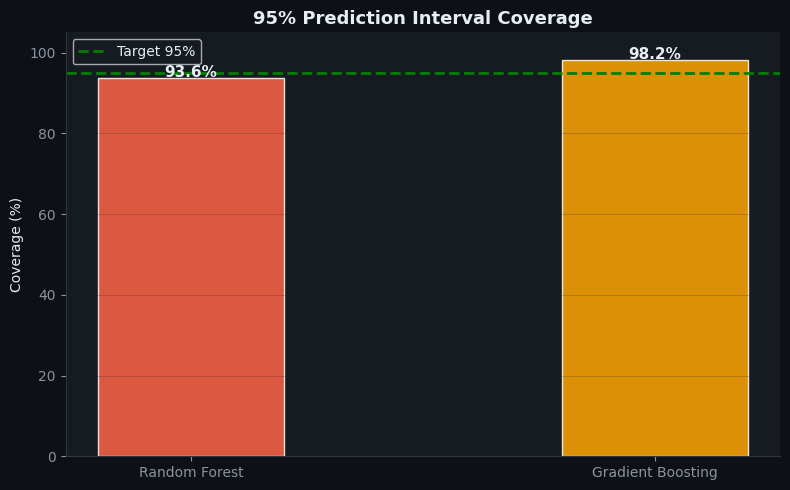

In [67]:
# COVERAGE COMPARISON
plt.figure(figsize=(8, 5))
models_cov = ['Random Forest', 'Gradient Boosting']
coverage   = [rf_coverage, gb_coverage]
colors_cov = ['tomato', 'orange']
bars = plt.bar(models_cov, coverage, color=colors_cov, alpha=0.85, edgecolor='white', width=0.4)
plt.axhline(95, color='green', lw=2, linestyle='--', label='Target 95%')
for bar, val in zip(bars, coverage):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')
plt.title('95% Prediction Interval Coverage', fontsize=13, fontweight='bold')
plt.ylabel('Coverage (%)')
plt.ylim(0, 105)
plt.legend(); plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

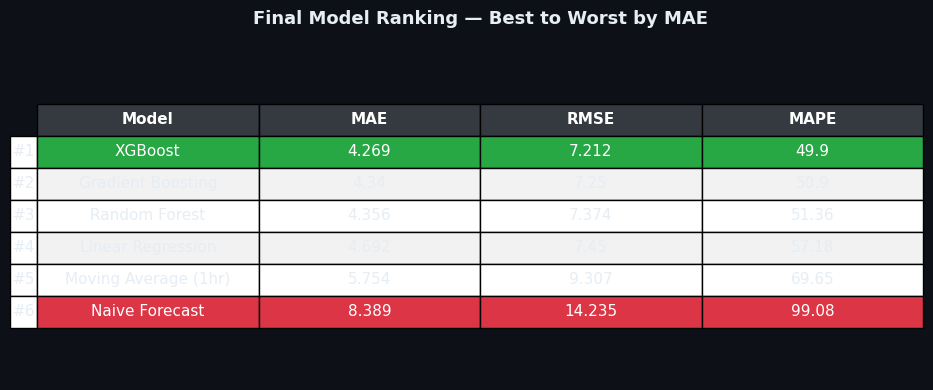

In [68]:
# FINAL MODEL RANKING TABLE (Improved Visibility)

ranked = results_df.sort_values('MAE').reset_index(drop=True)
ranked.index += 1

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')
table = ax.table(
    cellText  = ranked.values,
    colLabels = ranked.columns,
    rowLabels = [f'#{i}' for i in ranked.index],
    cellLoc   = 'center',
    loc       = 'center')

# Font & scaling
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.4, 1.8)

# --- Styling ---
# Header styling (dark background + white text)
for j in range(len(ranked.columns)):
    cell = table[0, j]
    cell.set_facecolor('#343a40')   # dark gray
    cell.get_text().set_color('white')
    cell.get_text().set_weight('bold')

# Alternate row colors
for i in range(1, len(ranked) + 1):
    for j in range(len(ranked.columns)):
        if i % 2 == 0:
            table[i, j].set_facecolor('#f2f2f2')  # light gray
        else:
            table[i, j].set_facecolor('#ffffff')  # white

# Highlight best model (top row)
for j in range(len(ranked.columns)):
    table[1, j].set_facecolor('#28a745')  # strong green
    table[1, j].get_text().set_color('white')

# Highlight worst model (last row)
for j in range(len(ranked.columns)):
    table[len(ranked), j].set_facecolor('#dc3545')  # strong red
    table[len(ranked), j].get_text().set_color('white')

ax.set_title(
    'Final Model Ranking — Best to Worst by MAE',
    fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

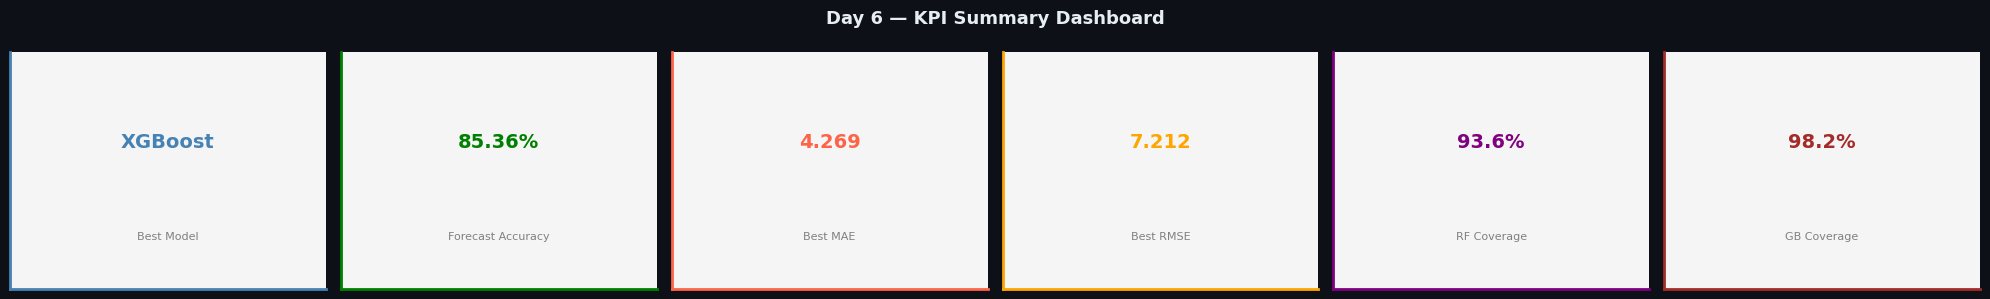


Day 6 done.

Best model  : XGBoost
Accuracy    : 85.36%
RF Coverage : 93.6%
GB Coverage : 98.2%

Ready for Day 7 — Streamlit App + Research Paper + Executive Summary.


In [69]:
# KPI DASHBOARD
kpis = [
    ('Best Model',         best_model,          'steelblue'),
    ('Forecast Accuracy',  f'{forecast_acc}%',  'green'),
    ('Best MAE',           str(best_mae),        'tomato'),
    ('Best RMSE',          str(best_rmse),       'orange'),
    ('RF Coverage',        f'{rf_coverage:.1f}%','purple'),
    ('GB Coverage',        f'{gb_coverage:.1f}%','brown'),
]

fig, axes = plt.subplots(1, 6, figsize=(20, 3))
fig.suptitle('Day 6 — KPI Summary Dashboard', fontsize=13, fontweight='bold')

for ax, (label, value, color) in zip(axes, kpis):
    ax.set_facecolor('#f5f5f5')
    for sp in ax.spines.values():
        sp.set_edgecolor(color)
        sp.set_linewidth(2)
    ax.text(0.5, 0.62, value, ha='center', va='center',
            transform=ax.transAxes, fontsize=14, fontweight='900', color=color)
    ax.text(0.5, 0.22, label, ha='center', va='center',
            transform=ax.transAxes, fontsize=8, color='gray')
    ax.set_xticks([]); ax.set_yticks([])

plt.tight_layout()
plt.show()

print("\nDay 6 done.")
print(f"\nBest model  : {best_model}")
print(f"Accuracy    : {forecast_acc}%")
print(f"RF Coverage : {rf_coverage:.1f}%")
print(f"GB Coverage : {gb_coverage:.1f}%")
print("\nReady for Day 7 — Streamlit App + Research Paper + Executive Summary.")

In [71]:
import pickle

# Save all trained models
with open('rf_model.pkl','wb') as f: pickle.dump(rf,f)
with open('gb_model.pkl','wb') as f: pickle.dump(gb,f)
with open('lr_model.pkl','wb') as f: pickle.dump(lr,f)
with open('xgb_model.pkl','wb') as f: pickle.dump(xgb,f)

# Save GB quantile models from Day 6
with open('gb_low.pkl','wb') as f: pickle.dump(gb_lower_model, f)
with open('gb_high.pkl','wb') as f: pickle.dump(gb_upper_model, f)

# Save conformal interval values from Day 6
import json
with open('intervals.json', 'w') as f:
    json.dump({'lower_q': float(lower_q), 'upper_q': float(upper_q)}, f)

# Save feature columns list
with open('feat_cols.pkl', 'wb') as f: pickle.dump(feat_cols, f)

print("All models saved!")

# Download from Colab to your PC
from google.colab import files
files.download('rf_model.pkl')
files.download('gb_model.pkl')
files.download('lr_model.pkl')
files.download('xgb_model.pkl')
files.download('gb_low.pkl')
files.download('gb_high.pkl')
files.download('intervals.json')
files.download('feat_cols.pkl')

All models saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>